# Baseline Model Evaluation
This notebook evaluates the pre-trained `SamLowe/roberta-base-go_emotions` model to establish a strong baseline for our project. We can later use these results to compare against our own custom-trained models.

In [149]:
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Add the source folder to sys.path so we can import our modules
source_code_path = os.path.abspath('../source')
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from baseline_roberta import *
from general_preprocessing import *
from visualizations import *
from modeling import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [150]:
#!pip install huggingface-hub
!pip install ipywidgets

# Enable widgets for Jupyter
!jupyter nbextension enable --py widgetsnbextension

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot trust

Jupyter command `jupyter-nbextension` not found.


In [151]:
pip install dotenv

In [152]:
from dotenv import load_dotenv
import os

# Load the .env file
load_dotenv()

# Get the token
token = os.getenv('HUGGINGFACE_TOKEN')

if token:
    print(f"Token loaded: {token[:10]}...{token[-5:]}")  # Shows partial token    
else:
    print("No Hugging Face token found in .env (optional)")

Token loaded: hf_lrLVbeP...SuFvp


In [153]:
from huggingface_hub import login

# Log in with your Hugging Face token
# You can get your token at: https://huggingface.co/settings/tokens
login(token=os.getenv('HUGGINGFACE_TOKEN'))

# It will prompt you to enter your token
# After logging in, you can access the model

### 1. Load the Dataset

As seen in the exploration notebook, since the goal is to predict the emotions of a text based ONLY on the text itself, from now on we will only use the aggeregated dataset, which contains the text and the 28 emotion labels. The original dataset contains also other columns (e.g., source, author, etc.) that we will not use for our task. This new version of the dataset, has also in account that the problem is multilabeled, meaning that some texts have multiple emotions associated with it.

In [154]:
# Load the dataset using the utility function
dataset_original = load_dataset('../data/GoEmotions_multilabel.csv')

# Display the first few rows to verify it loaded correctly
dataset_original.head()

,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,"""If you don't wear BROWN AND ORANGE...YOU DON...",0,0,1,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,"""What do Scottish people look like?"" How I wo...",0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,"### A surprise, to be sure, but a welcome one",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,"'*Pray*, v. To ask that the laws of the unive...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,">it'll get invaded by tankie, unfortunately. ...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [155]:
# TODO: For testing purposes, we will work with a smaller subset of the dataset
dataset = dataset_original.head(1000).copy()

## <font color='#BFD72F' size=6>2 Modeling</font> <a class="anchor" id="4"></a>
  
[Back to TOC](toc)

After exploring the dataset, and having our pipeline for preprocessing created, we can move on to actually testing different models and understand how well they can predict the emotions of the texts.

To understand how different preprocessing techniques affect the performance of the model, we will apply three different preprocessings, and use these 3 versions of the text throughout the rest of the project.

### <font color='#BFD72F' size=6>2.1 Creating preprocessed versions</font> <a class="anchor" id="2.1"></a>
  
[Back to TOC](toc)

In [156]:
# Text with translated emojis, hastags, urls (basically the minimal preprocessing to be done, that the allows the model to fully understand every component of the text, without taking the 'emotion' out of it. ) 
dataset['01_minimal_preprocessing'] = dataset['text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=False,  
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=False,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [157]:
# Medium Preprocessing: Text with translated emojis, hastags, urls, punctuation removed, stopwords removed, diacritics converted, lowercased, lemmatized, and repeated characters treated
dataset['02_medium_preprocessing'] = dataset['01_minimal_preprocessing'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=False,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [158]:
# Harsh Preprocessing: Text with translated emojis, hastags, urls, punctuation removed, stopwords removed, diacritics converted, lowercased, lemmatized, and repeated characters treated
dataset['03_harsh_preprocessing'] = dataset['02_medium_preprocessing'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_emojis=True,             
        no_hashtags=True,           
        hashtag_retain_words=True,  
        no_newlines=True,           
        no_urls=True,
        no_punctuation=True,  
        no_stopwords=True,
        custom_stopwords=[],
        stopwords_tokeep=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=False,
        list_pos=[],
        pos_tags_list='no_pos',
        tokenized_output=False,
        stemmed=False,
        treat_repeated_chars=False
    )
)

In [159]:
# Follow an example
print("Original Text Sample:\n")
print(dataset[['text']].iloc[818].values)

print("\nMinimal Preprocessing Sample:\n")
print(dataset[['01_minimal_preprocessing']].iloc[818].values)

print("\nMedium Preprocessing Sample:\n")
print(dataset[['02_medium_preprocessing']].iloc[818].values)

print("\nHarsh Preprocessing Sample:\n")
print(dataset[['03_harsh_preprocessing']].iloc[818].values)

Original Text Sample:

["/uj I would've thought this was pics had it not been for your commie t"]

Minimal Preprocessing Sample:

['/uj I would have thought this was pics had it not been for your commie t']

Medium Preprocessing Sample:

['uj i would have thought this was pics had it not been for your commie t']

Harsh Preprocessing Sample:

['uj would thought pics commie']


Just as some final exploration we will see the most common words in the 3 different preprocessings.

In [160]:
# Analyze Minimal preprocessing
vectorizer = CountVectorizer(max_df=0.8, min_df=5)
X_minimal = vectorizer.fit_transform(dataset['01_minimal_preprocessing'])
words_minimal = vectorizer.get_feature_names_out()
total_counts_minimal = X_minimal.sum(axis=0).A1
df_words_minimal = pd.DataFrame({'word': words_minimal, 'count': total_counts_minimal}).sort_values(by='count', ascending=False)
print("Top 10 words (Minimal preprocessing):")
print(df_words_minimal.head(10))

# Analyze Medium preprocessing
X_medium = vectorizer.fit_transform(dataset['02_medium_preprocessing'])
words_medium = vectorizer.get_feature_names_out()
total_counts_medium = X_medium.sum(axis=0).A1
df_words_medium = pd.DataFrame({'word': words_medium, 'count': total_counts_medium}).sort_values(by='count', ascending=False)
print("\nTop 10 words (Medium preprocessing):")
print(df_words_medium.head(10))

# Analyze Harsh preprocessing
X_harsh = vectorizer.fit_transform(dataset['03_harsh_preprocessing'])
words_harsh = vectorizer.get_feature_names_out()
total_counts_harsh = X_harsh.sum(axis=0).A1
df_words_harsh = pd.DataFrame({'word': words_harsh, 'count': total_counts_harsh}).sort_values(by='count', ascending=False)
print("\nTop 10 words (Harsh preprocessing):")
print(df_words_harsh.head(10))

Top 10 words (Minimal preprocessing):
     word  count
125    is    320
231   the    302
289   you    244
165  name    212
247    to    208
126    it    188
21    and    176
172   not    172
230  that    137
175    of    130

Top 10 words (Medium preprocessing):
     word  count
122    is    320
228   the    302
286   you    242
162  name    210
244    to    208
123    it    184
19    and    175
169   not    172
227  that    137
172    of    130

Top 10 words (Harsh preprocessing):
       word  count
113    name    210
93     like     50
61      get     38
185   would     36
102    love     34
124     one     33
120      oh     32
164    time     32
67     good     32
125  people     31


Word cloud saved to wordclouds/01_minimal_preprocessing.png


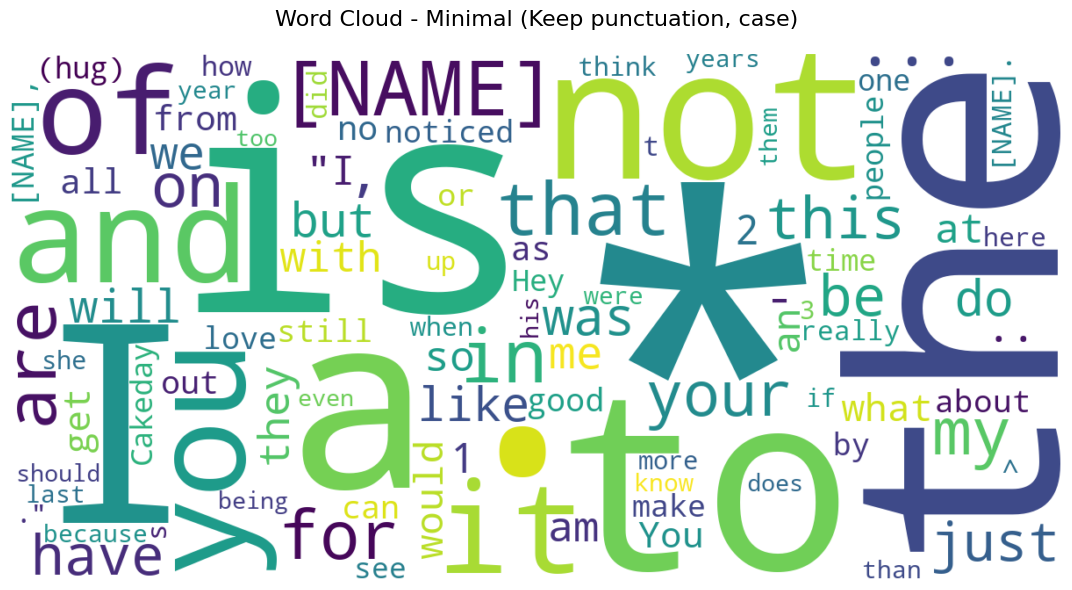

Word cloud saved to wordclouds/02_medium_preprocessing.png


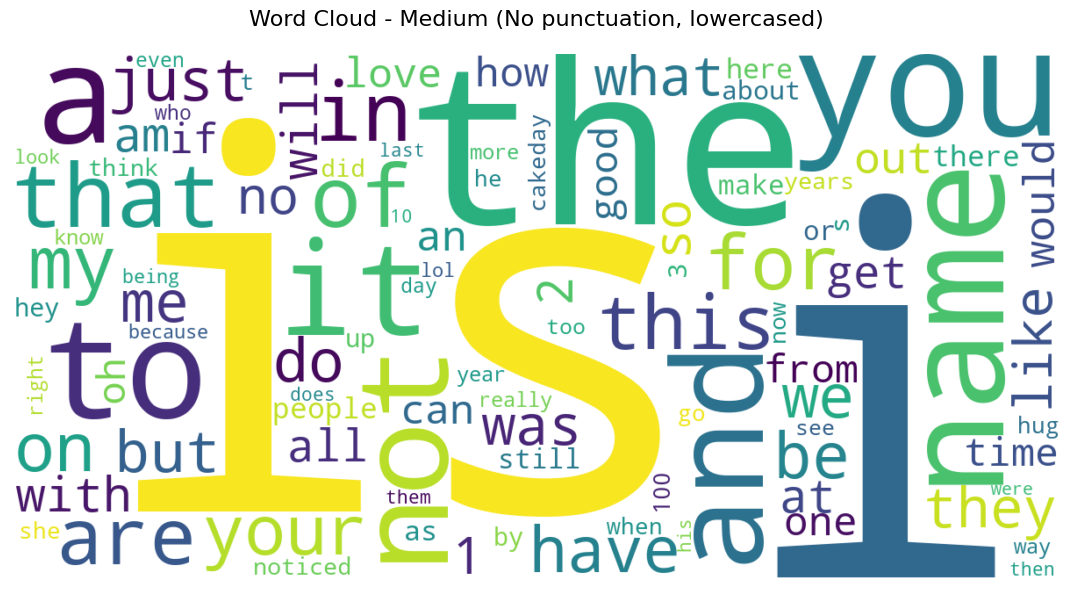

Word cloud saved to wordclouds/03_harsh_preprocessing.png


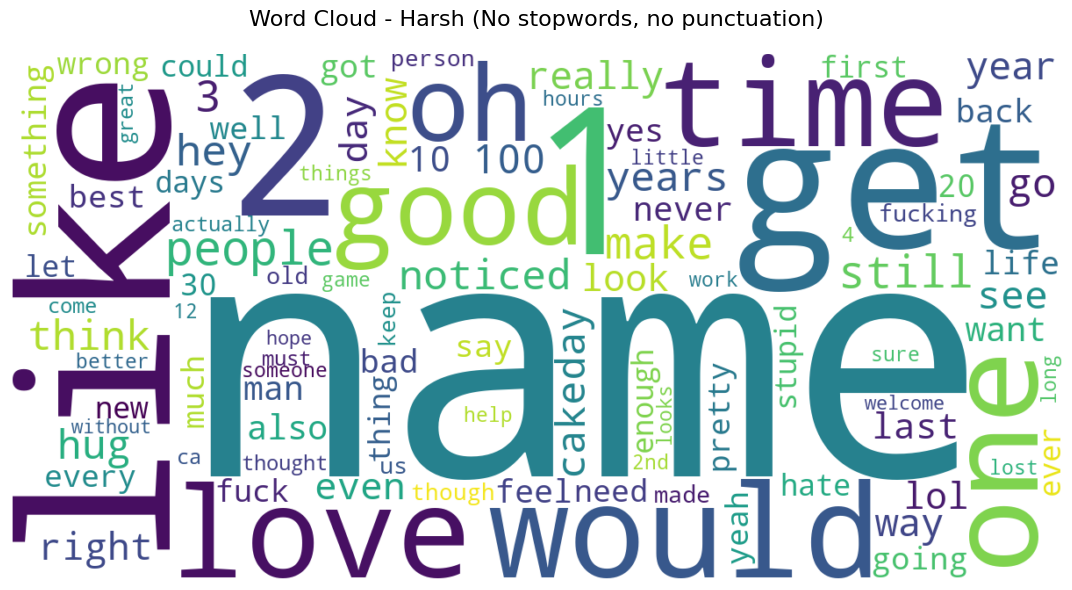

In [161]:
# Define your preprocessing versions
preprocessing_cols = {
    '01_minimal_preprocessing': 'Minimal (Keep punctuation, case)',
    '02_medium_preprocessing': 'Medium (No punctuation, lowercased)',
    '03_harsh_preprocessing': 'Harsh (No stopwords, no punctuation)'
}

# Generate word clouds for all versions
for col, description in preprocessing_cols.items():
    wordcloud_from_text(
        dataset[col],
        title=f"Word Cloud - {description}",
        max_words=100,
        colormap='viridis',
        save_path=f'wordclouds/{col}.png'
    )

It is expected that the more preprocessing we do the worse the model will perform since this tasks constitutes in classifing the emotions of the text, which is normally deeply correlated to punctuation, stopwords, and repeated characters. 

### 2. Apply the Baseline Model
Since evaluating all 200,000+ rows takes a significant amount of time, we first test it on a small sample of 100 rows.

We will use multiple models to evaluate the impact of different preprocessing techniques on the performance of emotion classification. The models we will use include:

In [162]:
MODELS = {
    'roberta_baseline': 'SamLowe/roberta-base-go_emotions',
    'bert_baseline': 'monologg/bert-base-cased-goemotions-original',
    'ekman_baseline': 'bhadresh-savani/bert-base-uncased-emotion'
}

In [163]:
# Define the experiments to run (Model and preprocessing combinations)
experiments = [
    # (text_column, model_key, output_column_name)
    ('01_minimal_preprocessing', 'roberta_baseline', 'pred_roberta_minimal'),
    ('02_medium_preprocessing', 'roberta_baseline', 'pred_roberta_medium'),
    ('03_harsh_preprocessing', 'roberta_baseline', 'pred_roberta_harsh'), 
    ('01_minimal_preprocessing', 'bert_baseline', 'pred_bert_minimal'),
    ('02_medium_preprocessing', 'bert_baseline', 'pred_bert_medium'),
    ('03_harsh_preprocessing', 'bert_baseline', 'pred_bert_harsh'),
    ('01_minimal_preprocessing', 'ekman_baseline', 'pred_ekman_minimal'),
    ('02_medium_preprocessing', 'ekman_baseline', 'pred_ekman_medium'),
    ('03_harsh_preprocessing', 'ekman_baseline', 'pred_ekman_harsh')
]

In [164]:
# Identify emotion columns
emotion_cols = [
    col for col in dataset.columns
    if col not in ['text', '01_minimal_preprocessing', '02_medium_preprocessing', '03_harsh_preprocessing']
    and not col.startswith('pred_')
]

# Create a new column with the list of true emotions for each row
dataset['true_emotions_label'] = dataset[emotion_cols].apply(
    lambda row: [col for col, val in row.items() if val == 1],
    axis=1
)

print(dataset[['text', 'true_emotions_label']].head())

                                                text  \
0   "If you don't wear BROWN AND ORANGE...YOU DON...   
1   "What do Scottish people look like?" How I wo...   
2     ### A surprise, to be sure, but a welcome one    
3   '*Pray*, v. To ask that the laws of the unive...   
4   >it'll get invaded by tankie, unfortunately. ...   

                               true_emotions_label  
0  [anger, annoyance, approval, optimism, neutral]  
1                                [curiosity, love]  
2                                       [surprise]  
3                                        [neutral]  
4                                        [neutral]  


In [165]:
# Create a copy of the dataset for testing
test_data = dataset.head(1000).copy()

In [166]:
# Run predictions for each preprocessing version and model
for text_col, model_key, output_col in experiments:
    # Print a header for clarity
    print(f"\n{'='*60}")
    print(f"Running: {model_key} on {text_col}")
    print(f"Output column: {output_col}")
    print('='*60)
    
    # Run the prediction function
    test_data = predict_with_model(
        df=test_data,
        text_column=text_col,
        model_name=MODELS[model_key],
        output_column=output_col,
        threshold=0.5
    )

# Verify all columns were added
print("\n" + "="*60)
print("ALL PREDICTION COLUMNS ADDED:")
print("="*60)
pred_cols = [col for col in test_data.columns if col.startswith('pred_')]
for col in pred_cols:
    print(f"  ✅ {col}")


Running: roberta_baseline on 01_minimal_preprocessing
Output column: pred_roberta_minimal
Using authentication token
Loading model: SamLowe/roberta-base-go_emotions...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1403.34it/s]


Generating predictions for 1000 rows...


Predicting with pred_roberta_minimal: 100%|██████████| 1000/1000 [02:09<00:00,  7.71it/s]


 Predictions saved to column: 'pred_roberta_minimal'

Running: roberta_baseline on 02_medium_preprocessing
Output column: pred_roberta_medium
Using authentication token
Loading model: SamLowe/roberta-base-go_emotions...


...

 Predictions saved to column: 'pred_ekman_medium'

Running: ekman_baseline on 03_harsh_preprocessing
Output column: pred_ekman_harsh
Using authentication token
Loading model: bhadresh-savani/bert-base-uncased-emotion...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2263.53it/s]


Generating predictions for 1000 rows...


Predicting with pred_ekman_harsh: 100%|██████████| 1000/1000 [01:25<00:00, 11.71it/s]


 Predictions saved to column: 'pred_ekman_harsh'

ALL PREDICTION COLUMNS ADDED:
  ✅ pred_roberta_minimal
  ✅ pred_roberta_medium
  ✅ pred_roberta_harsh
  ✅ pred_bert_minimal
  ✅ pred_bert_medium
  ✅ pred_bert_harsh
  ✅ pred_ekman_minimal
  ✅ pred_ekman_medium
  ✅ pred_ekman_harsh


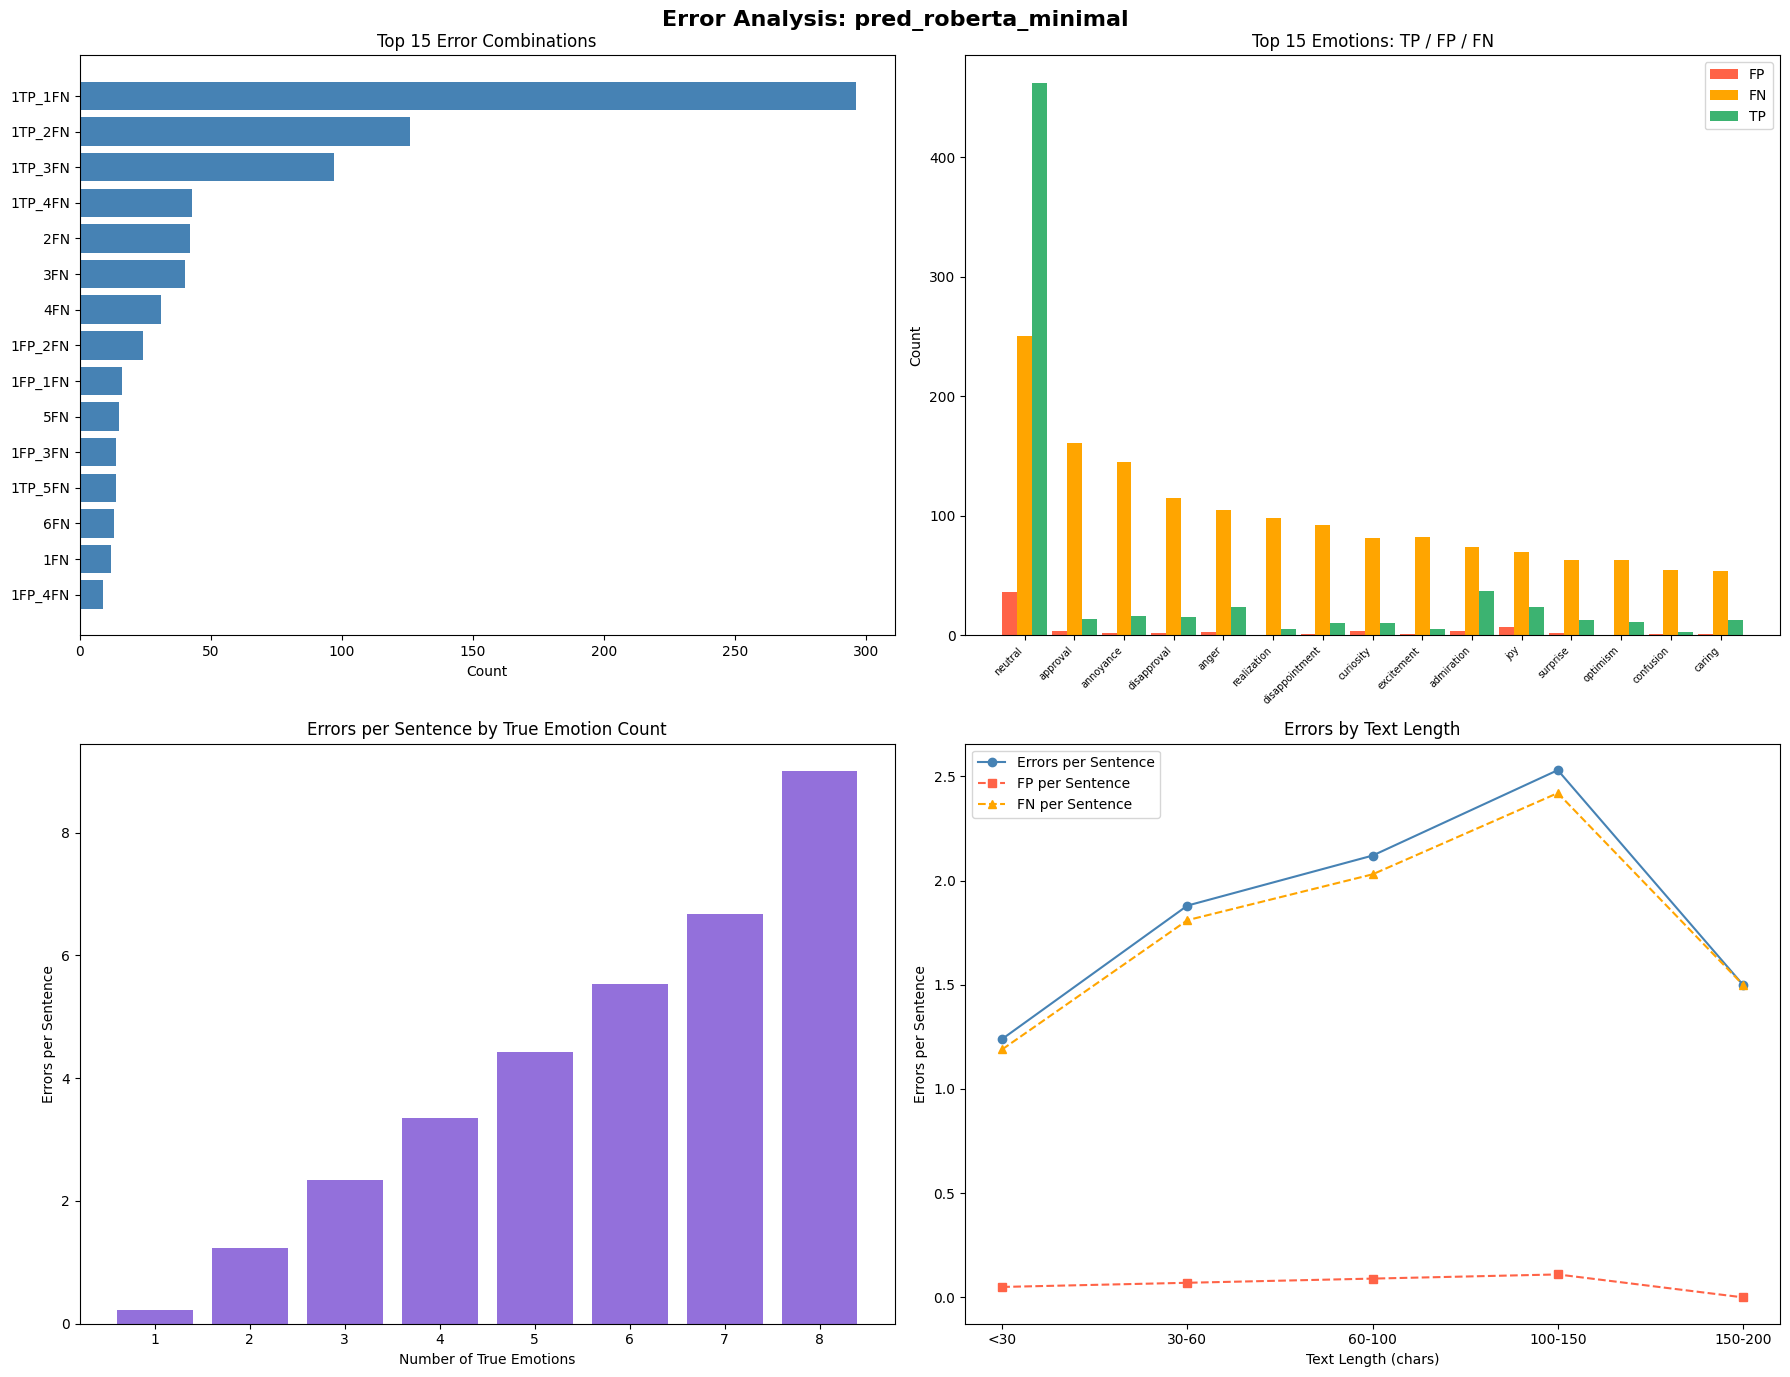

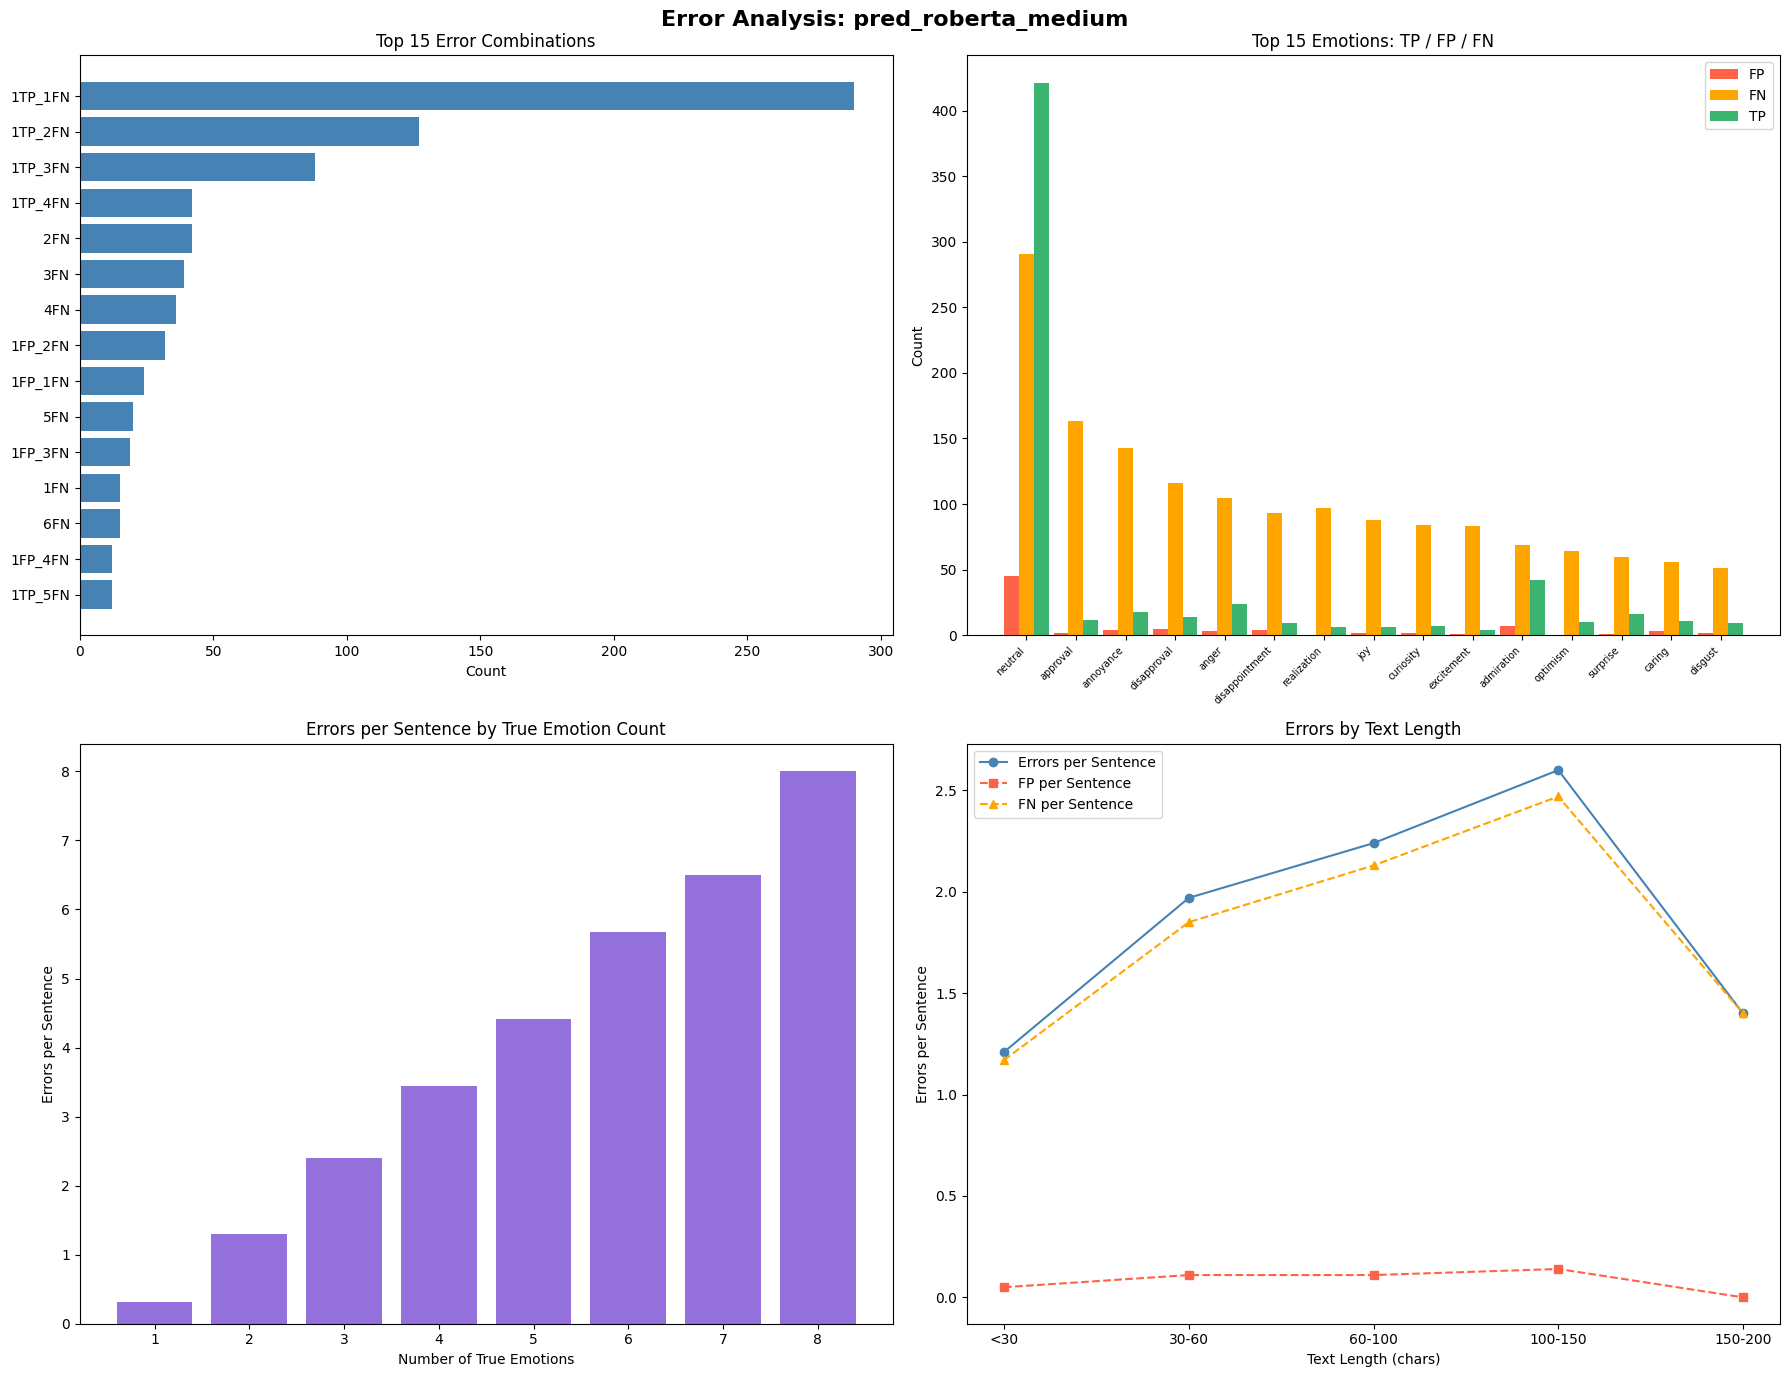

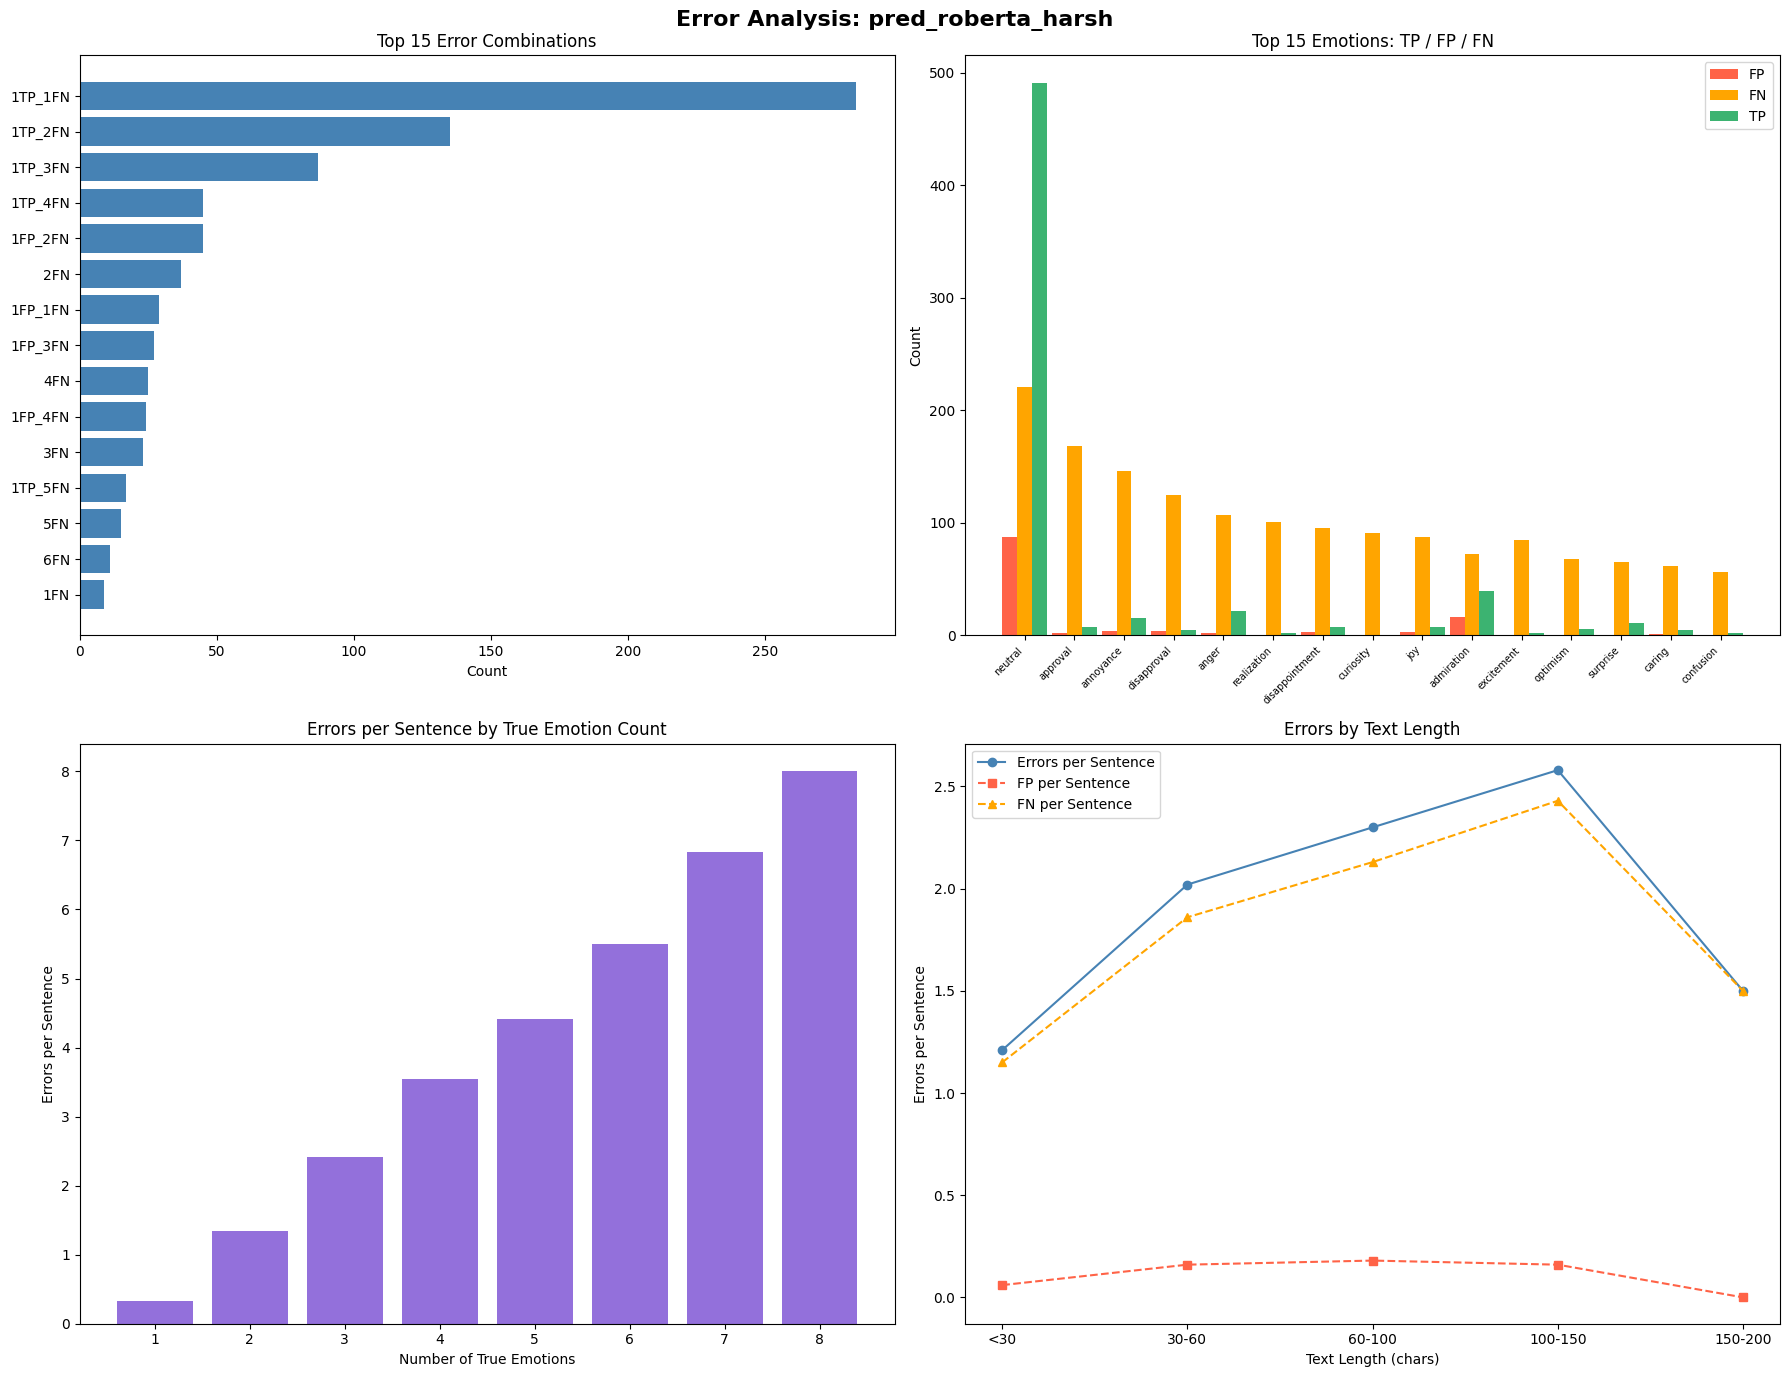

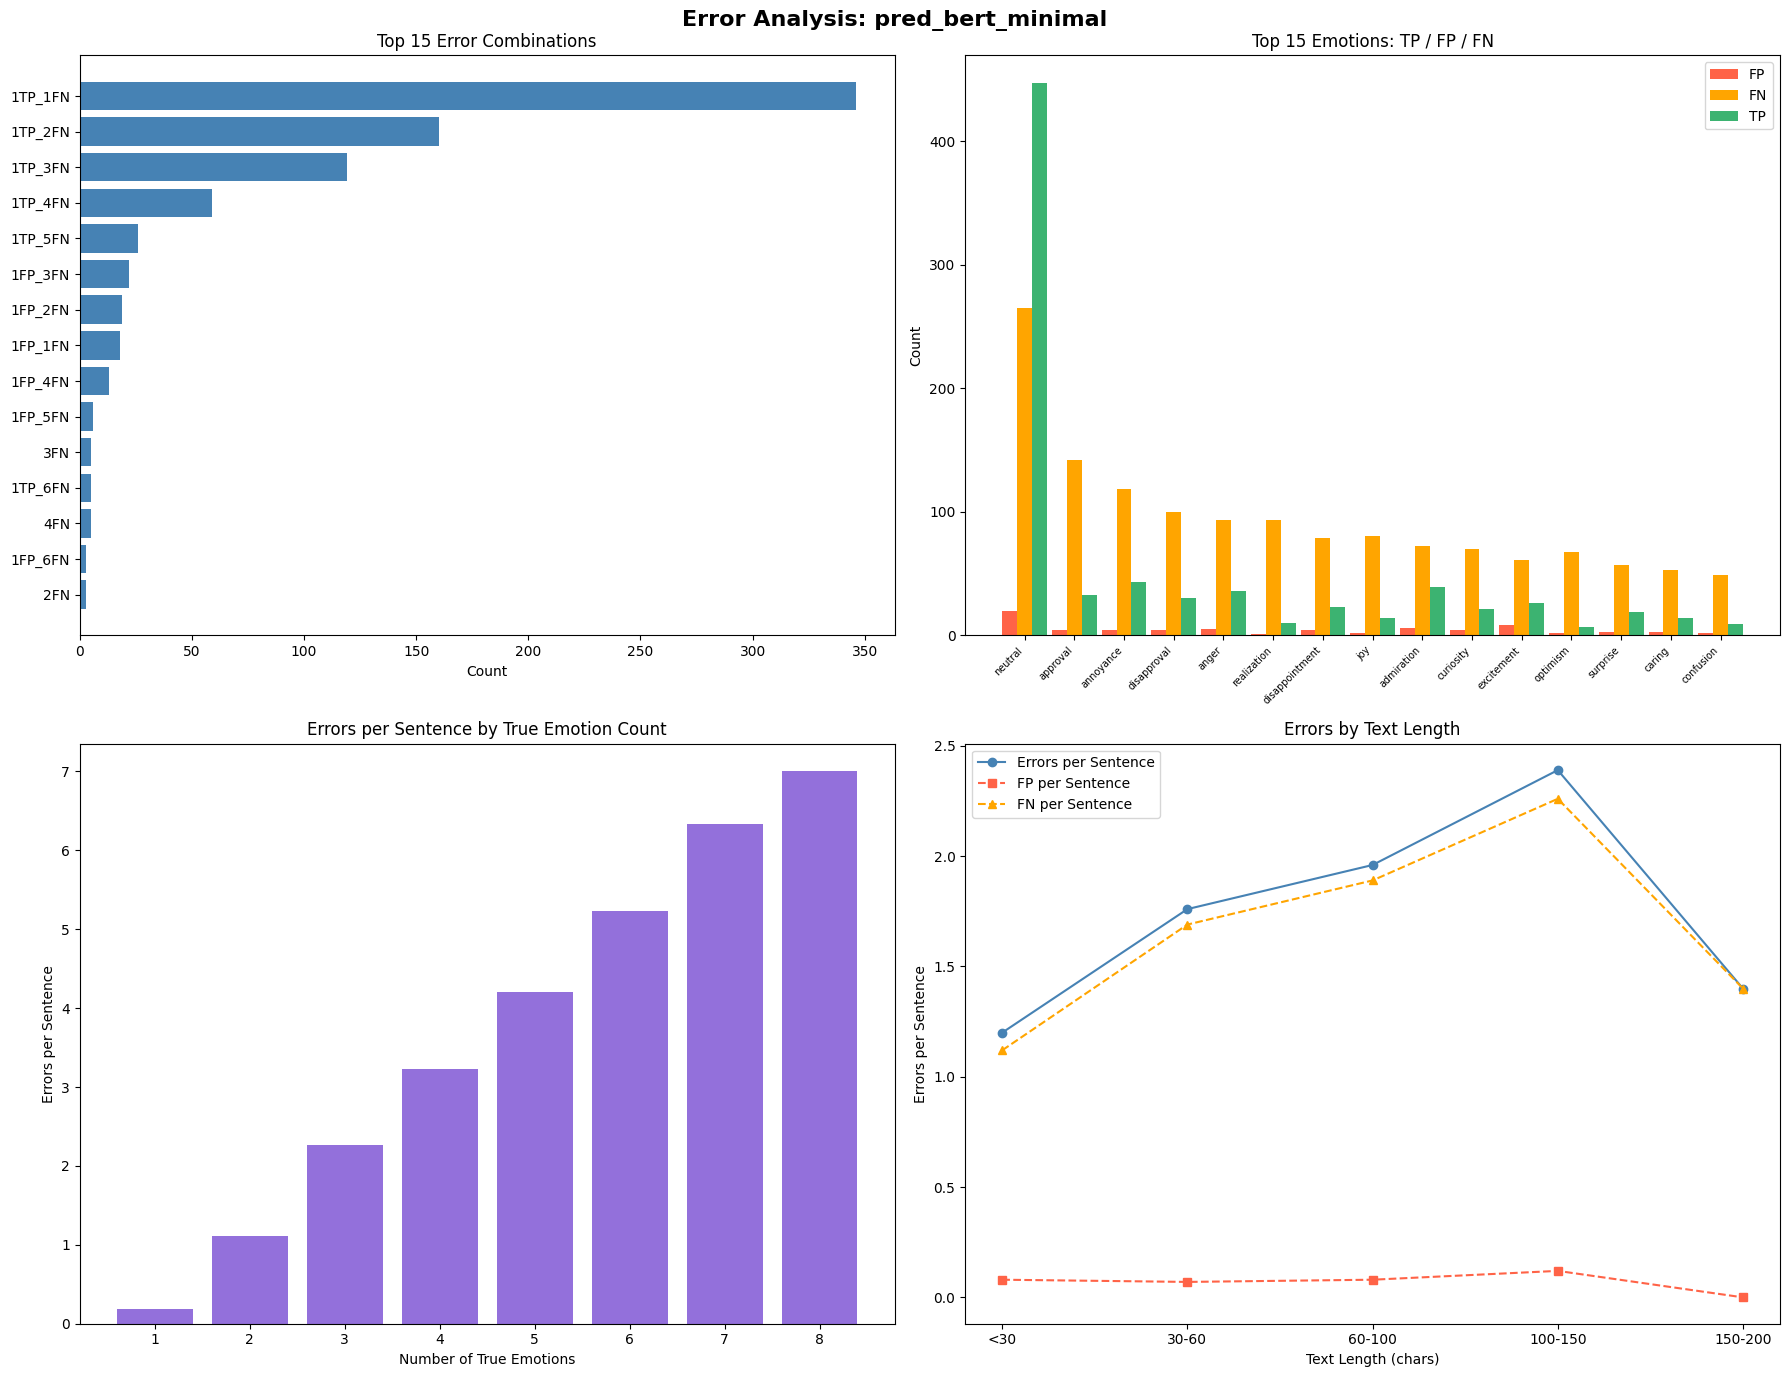

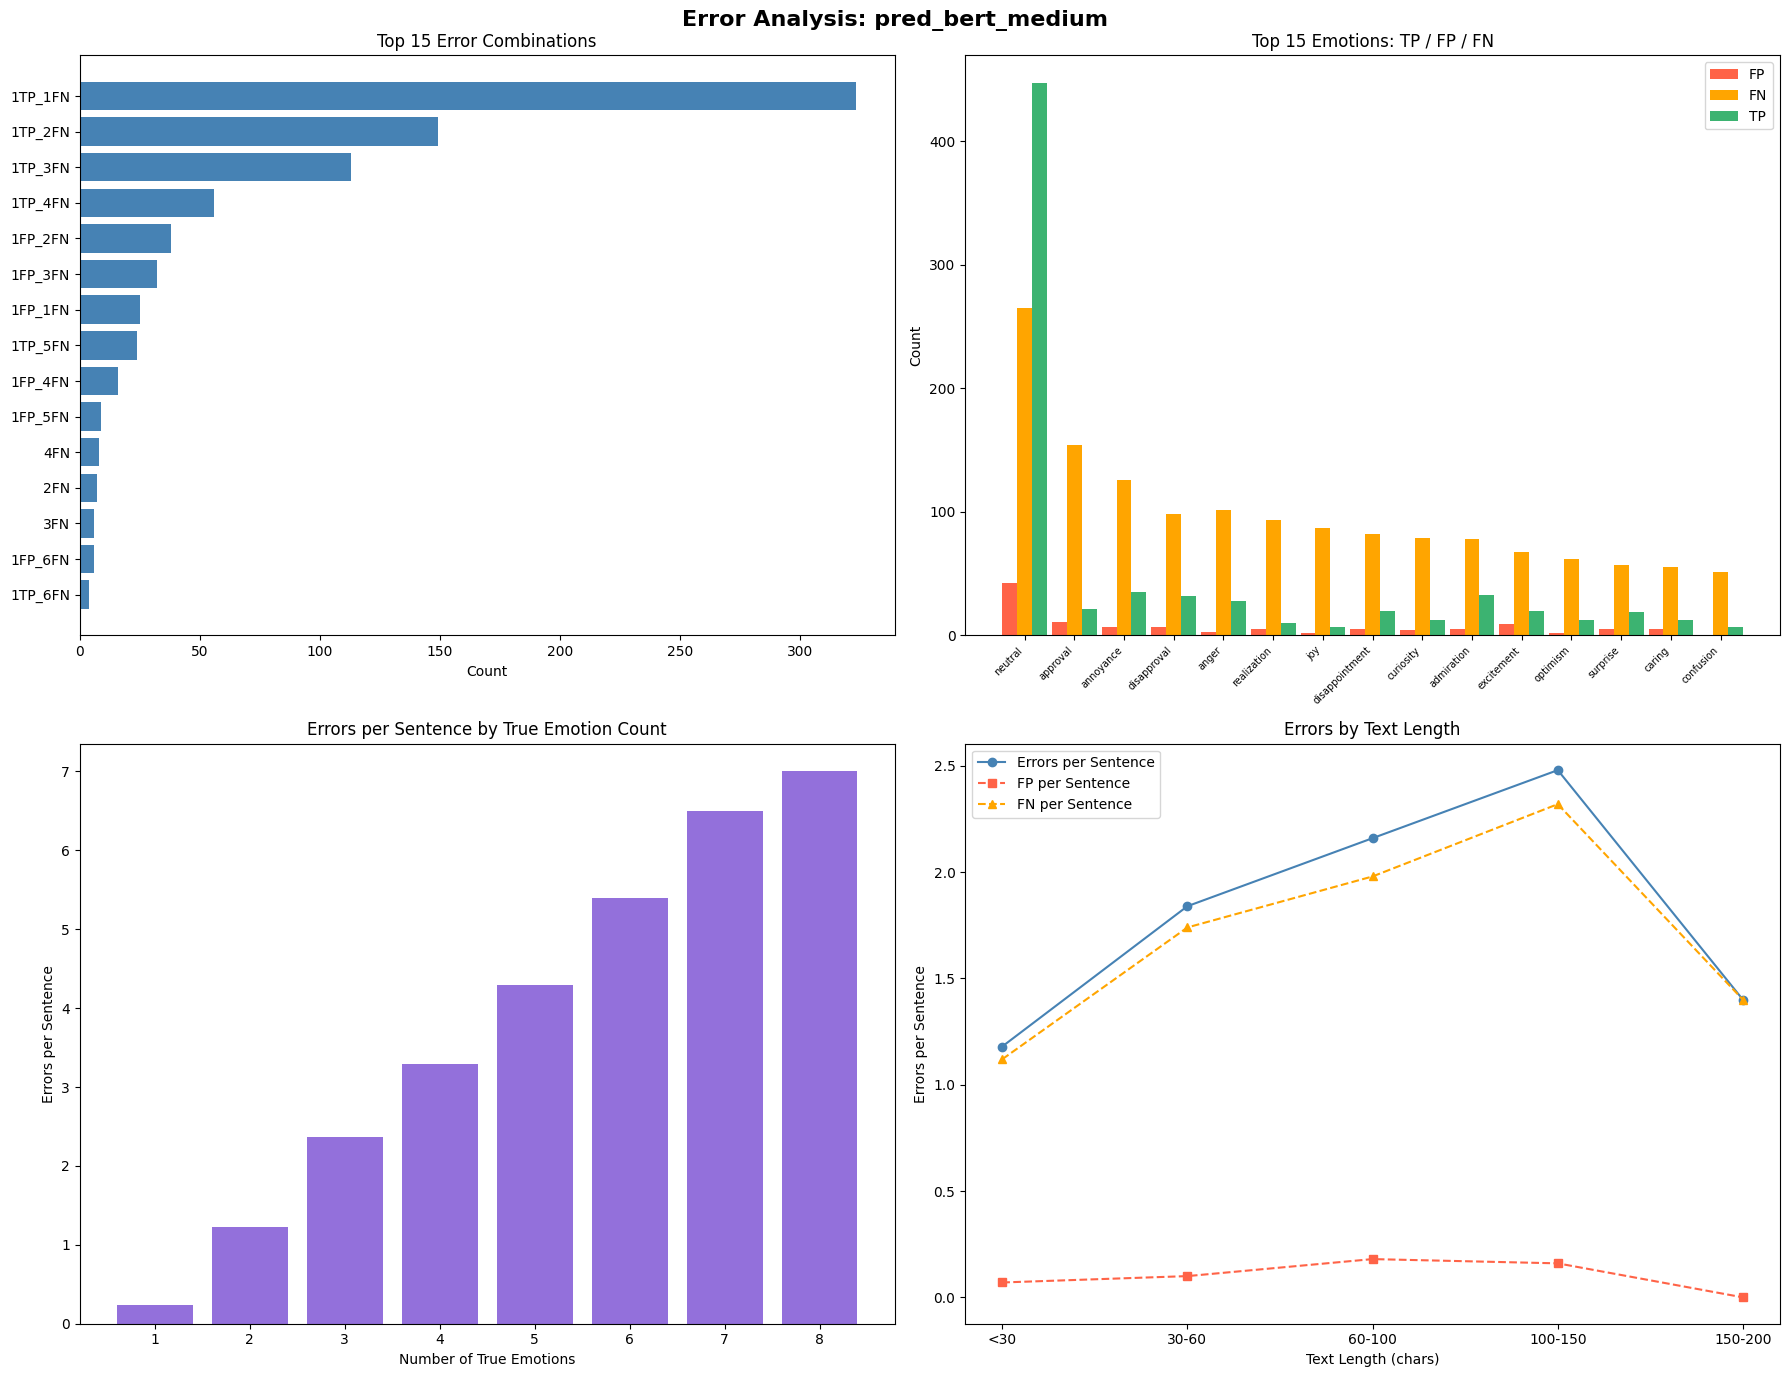

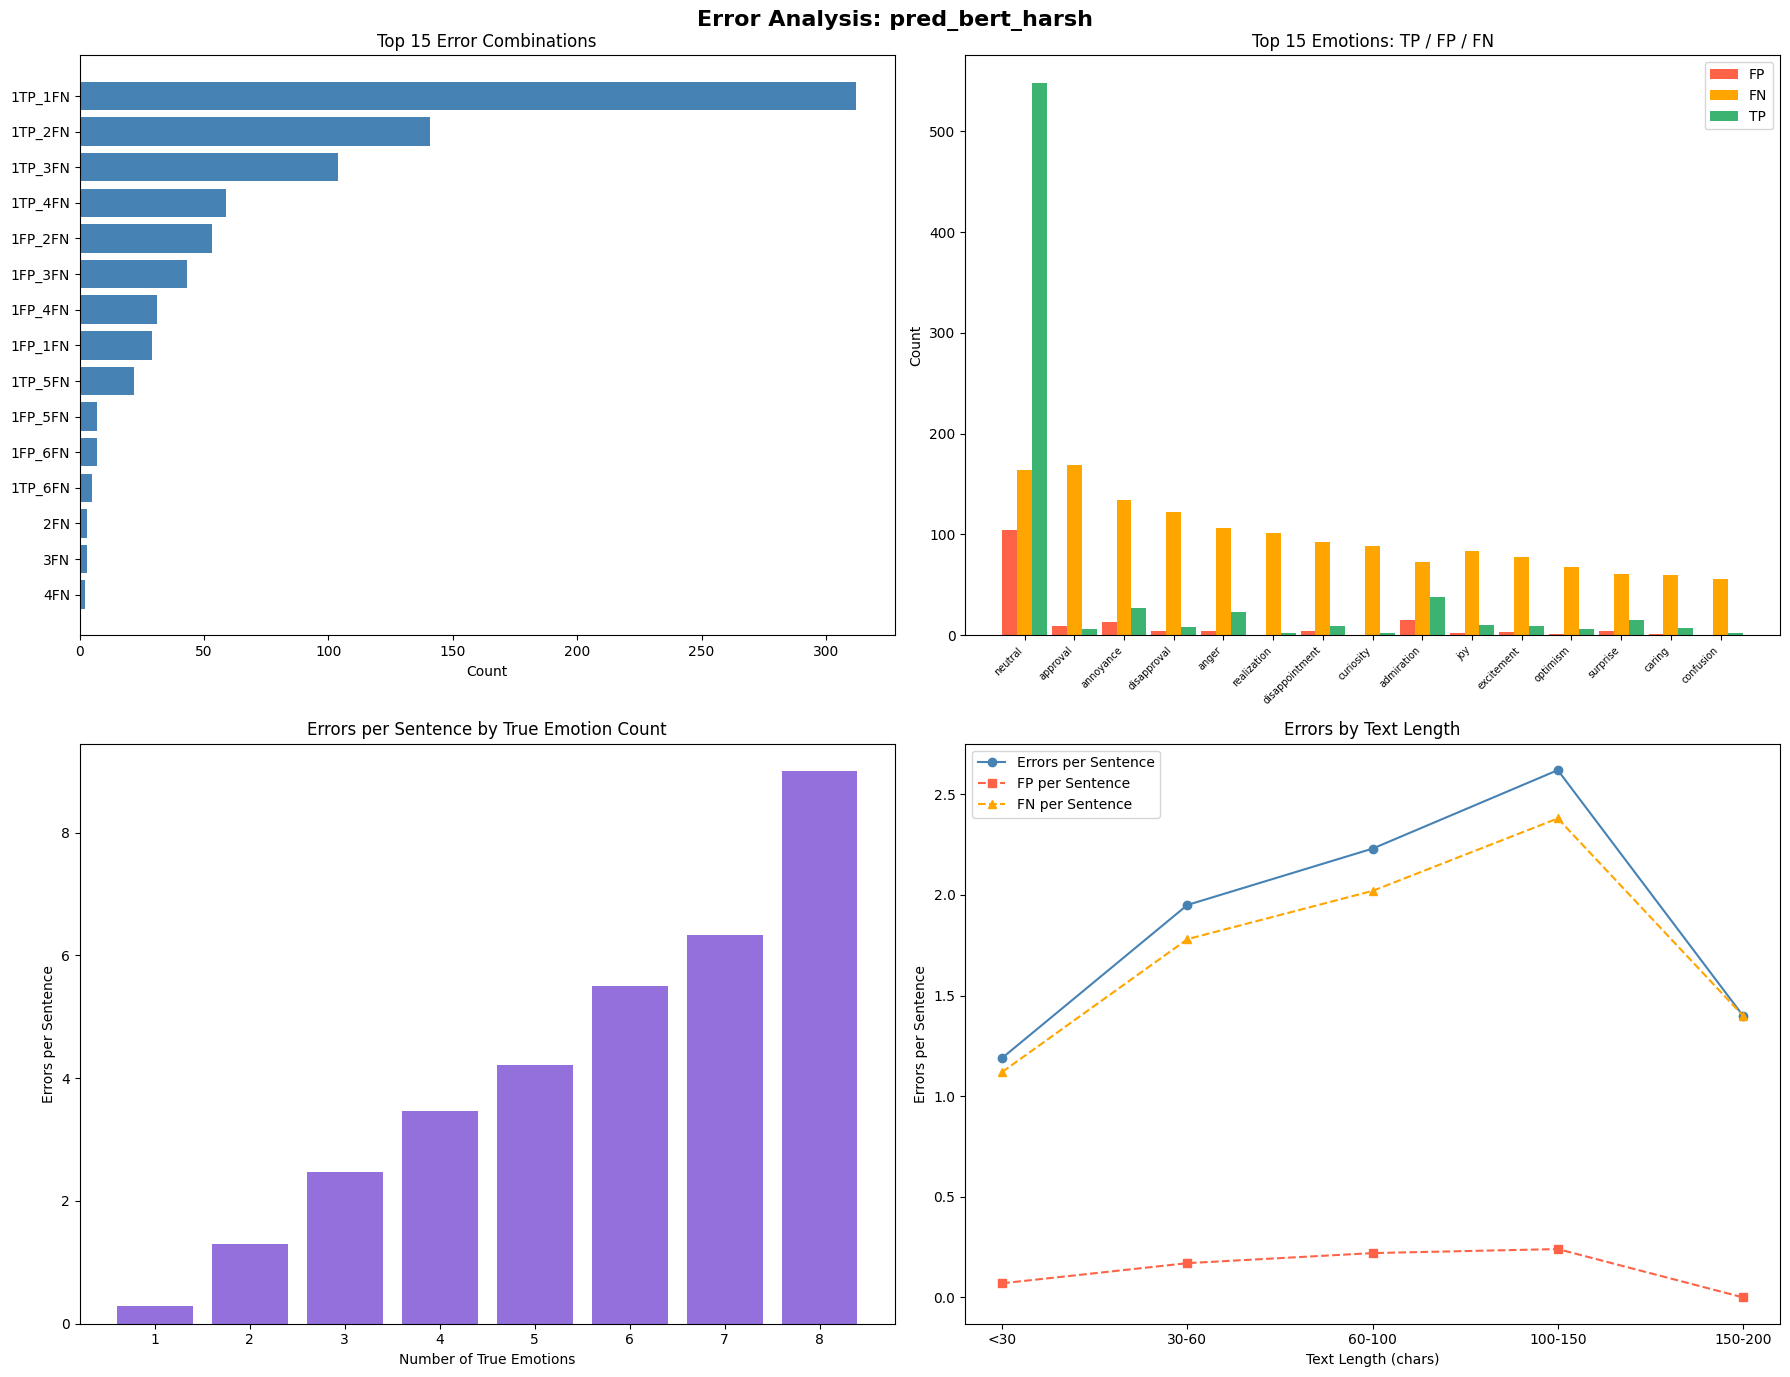

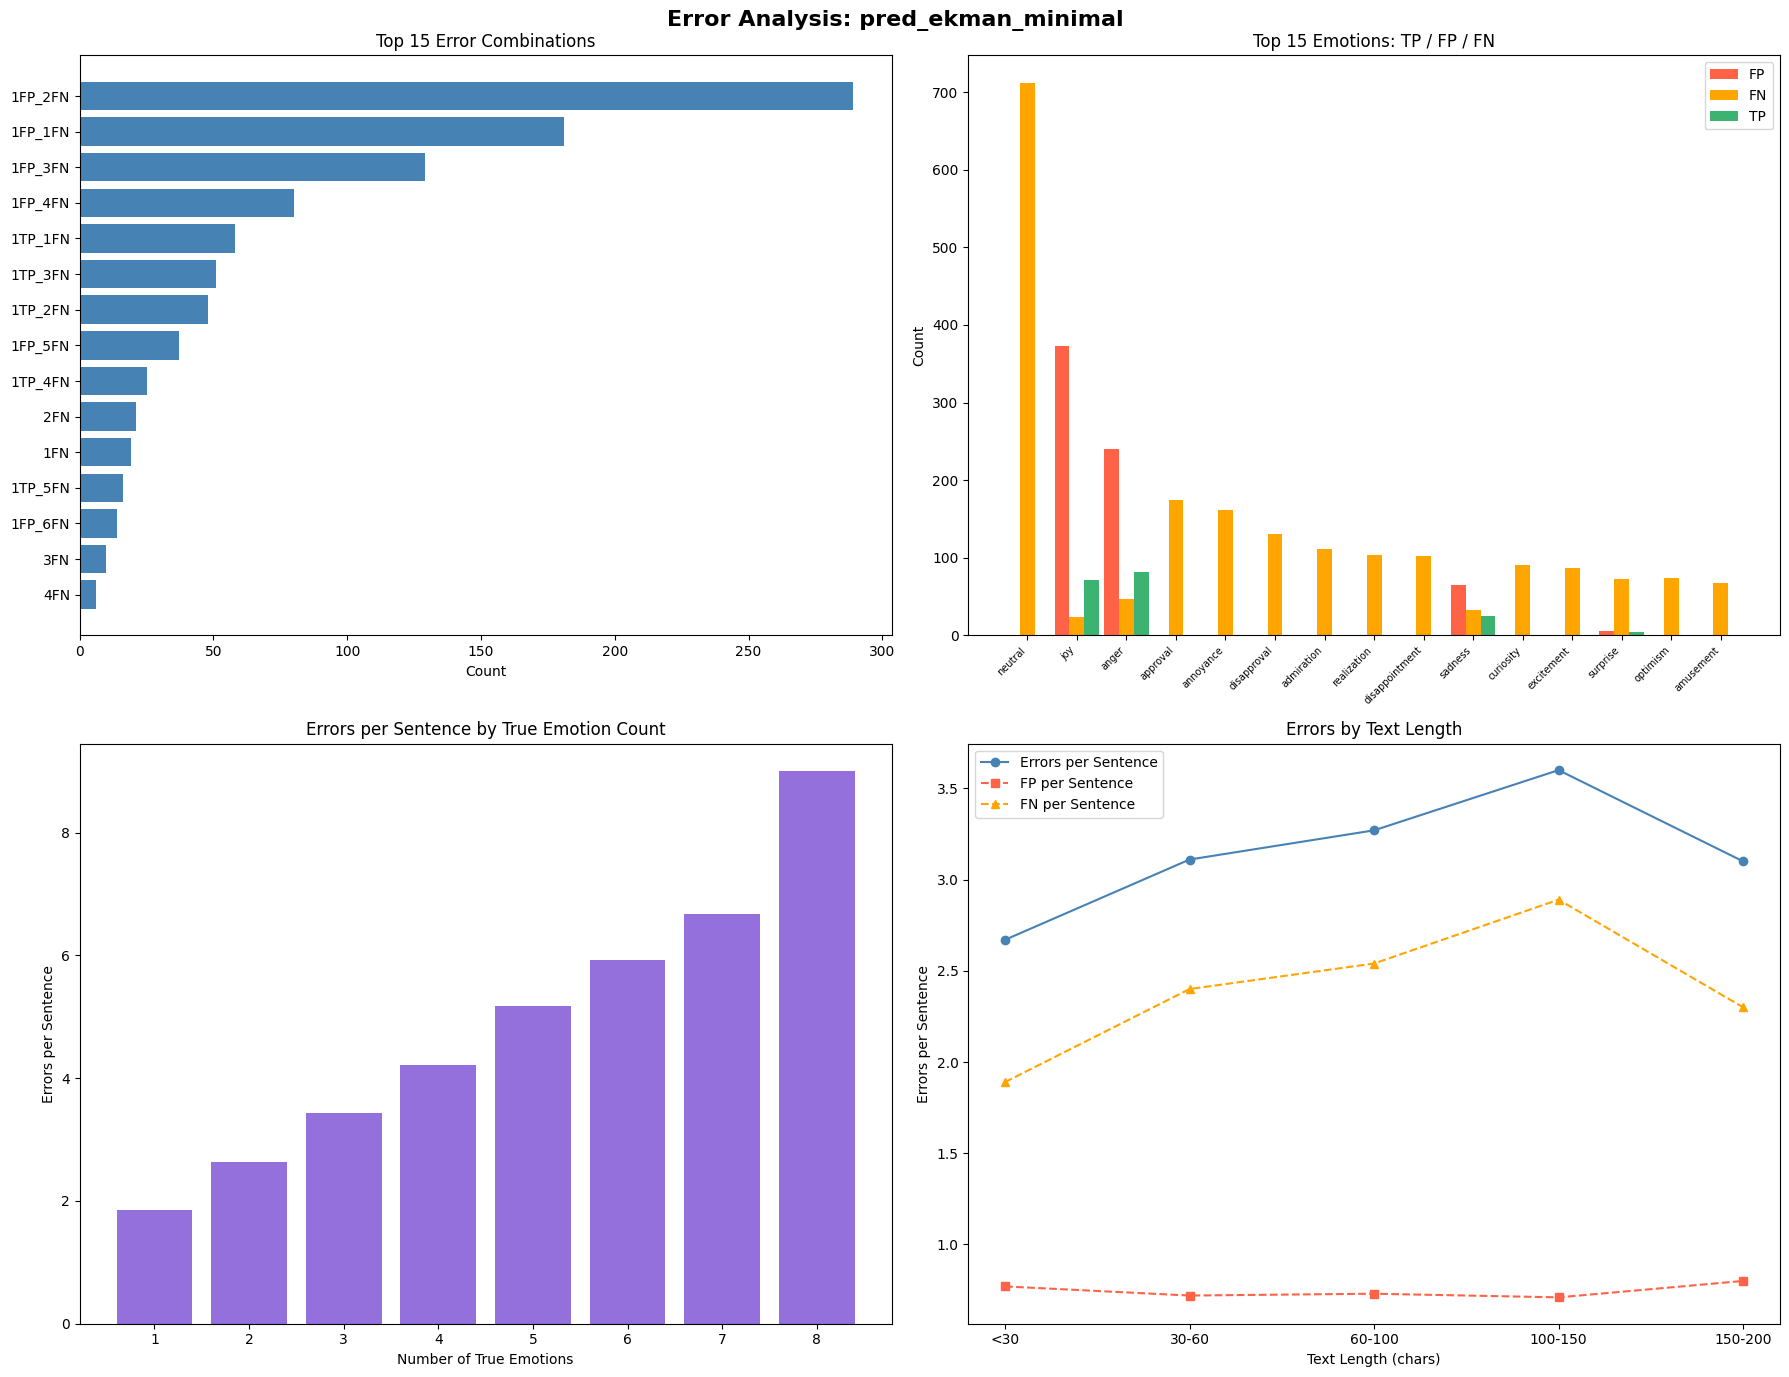

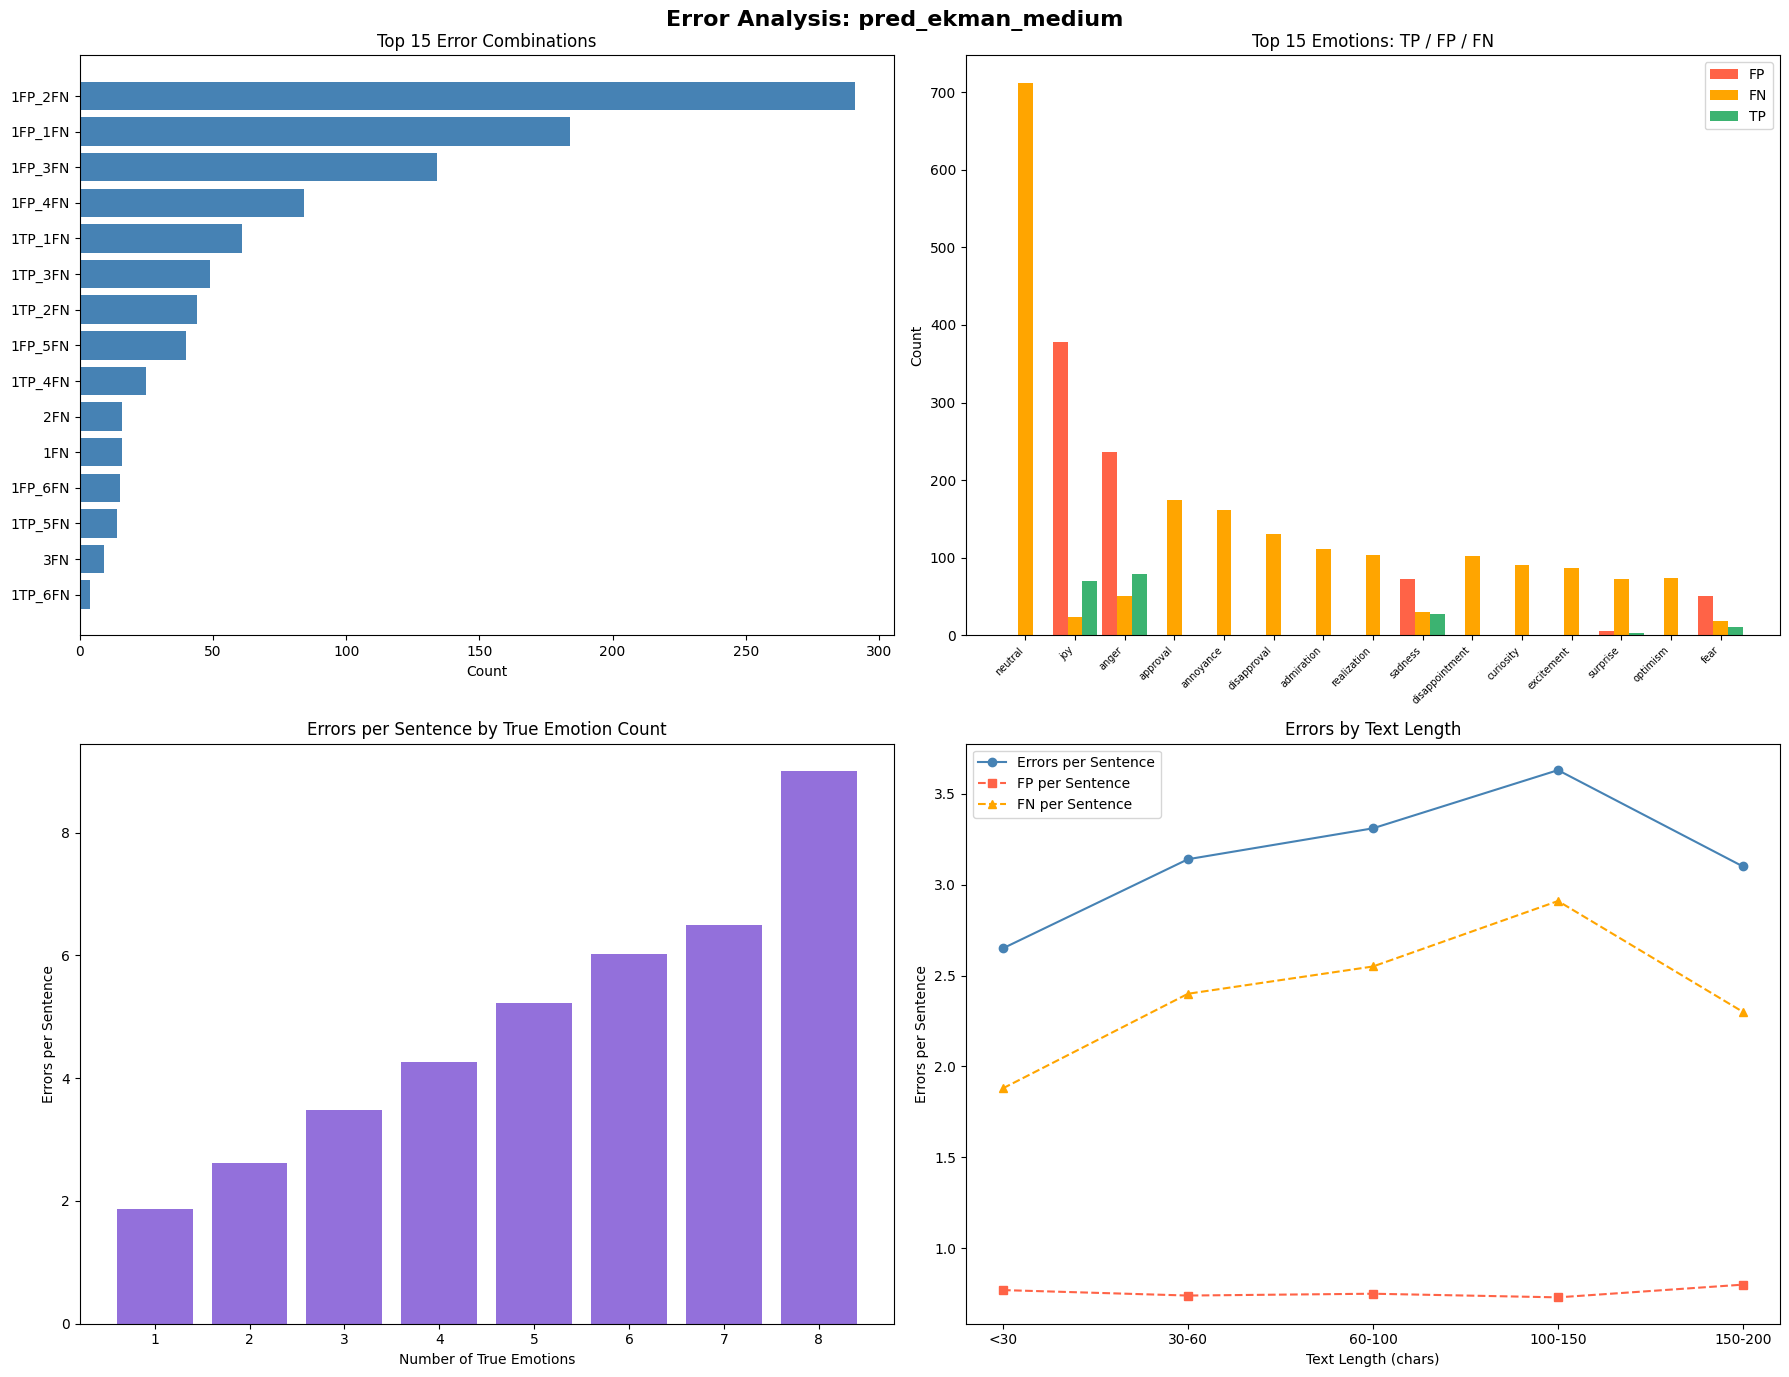

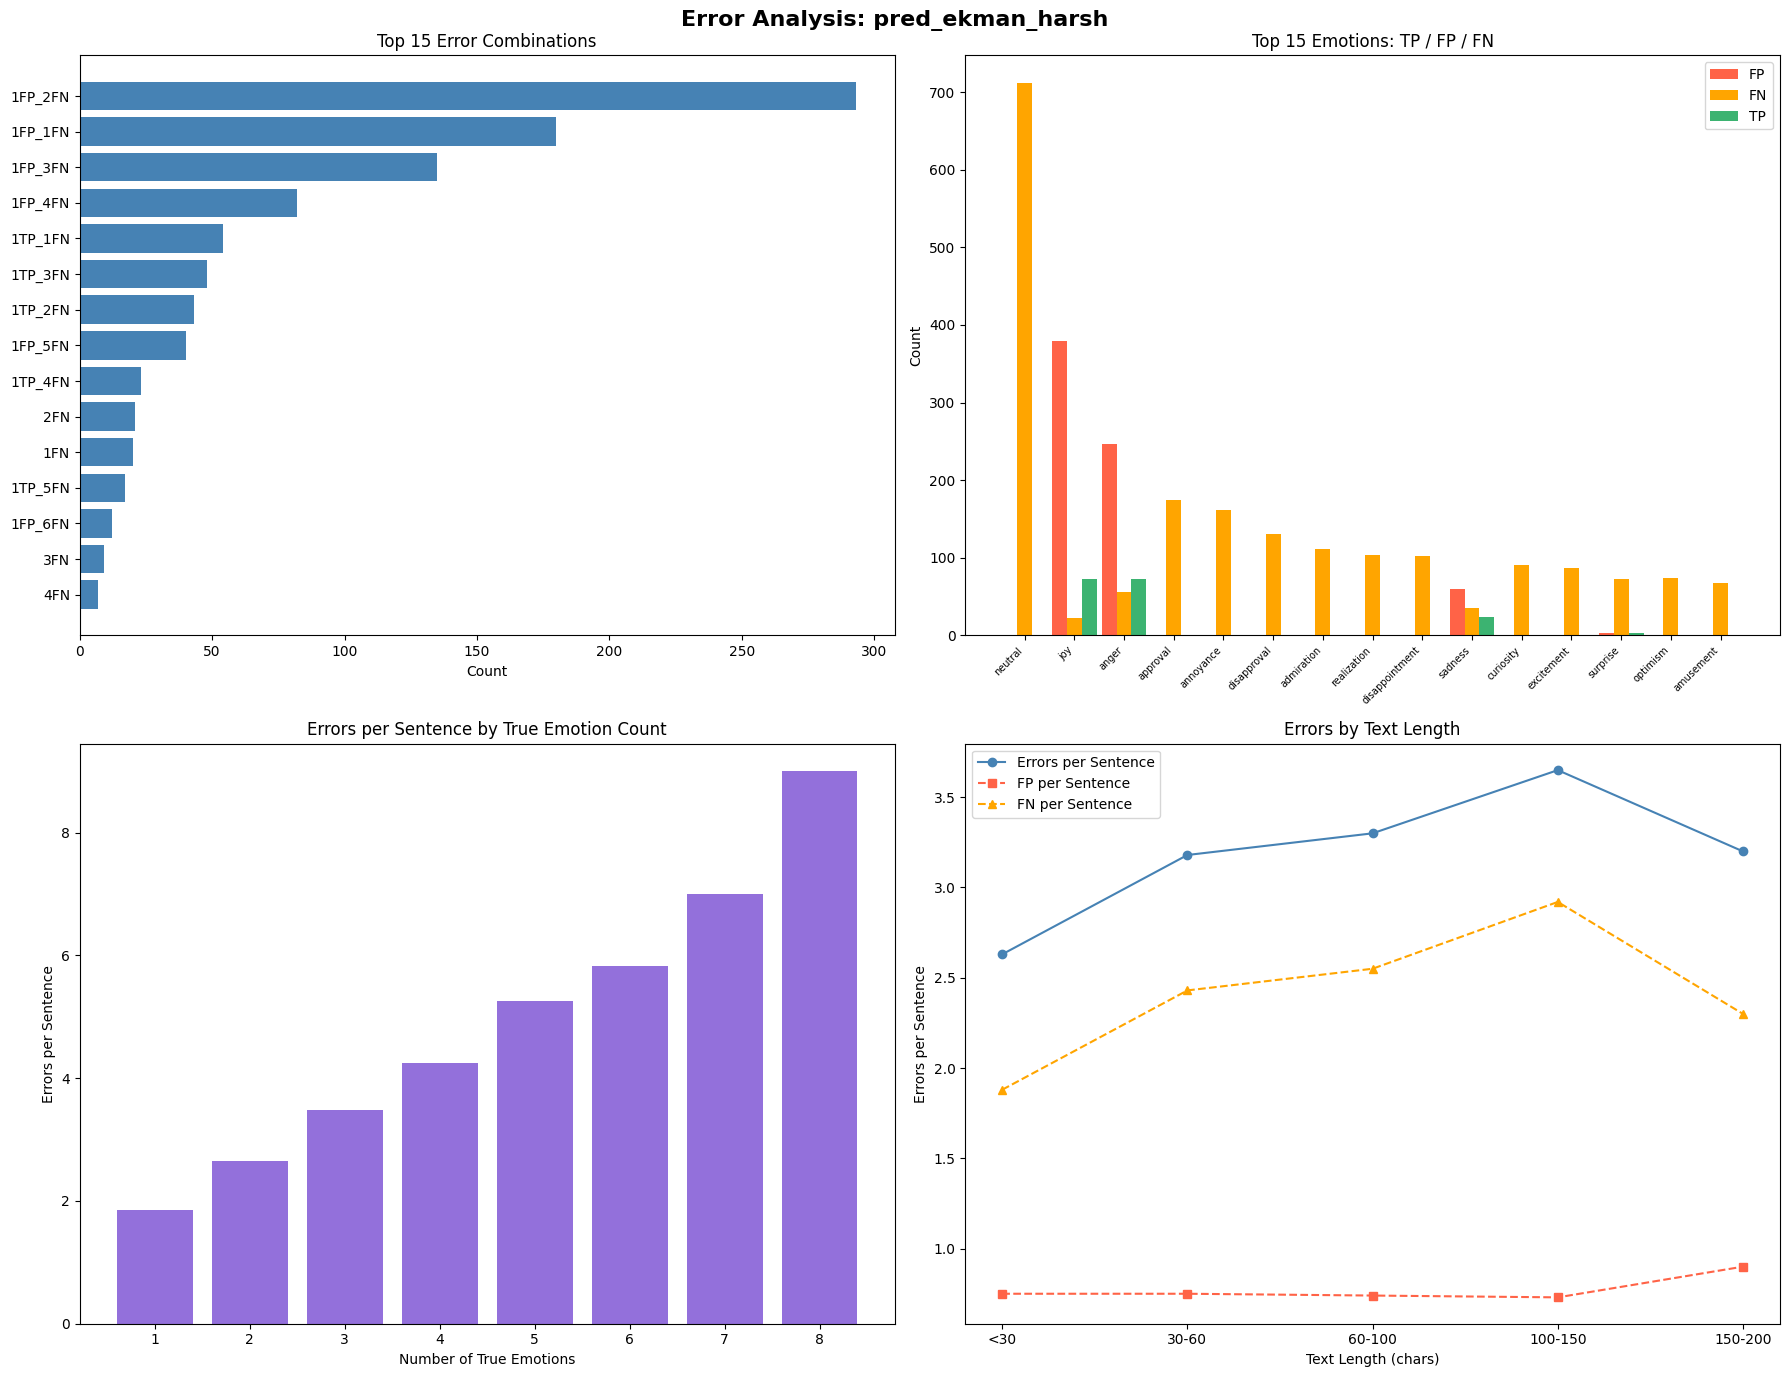

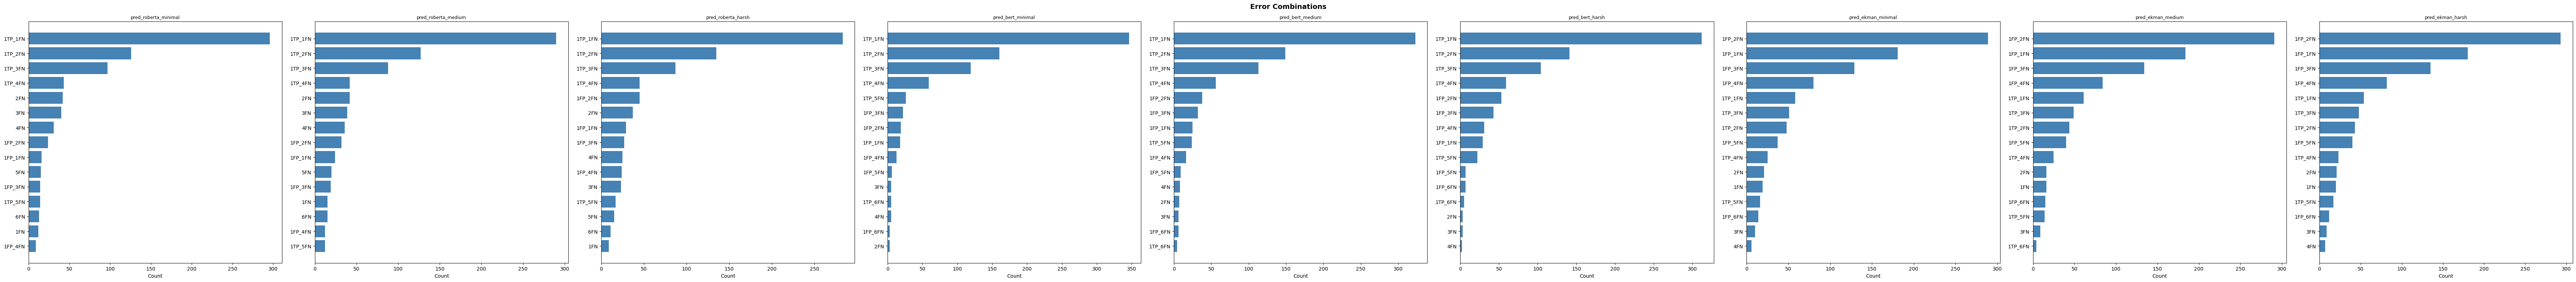

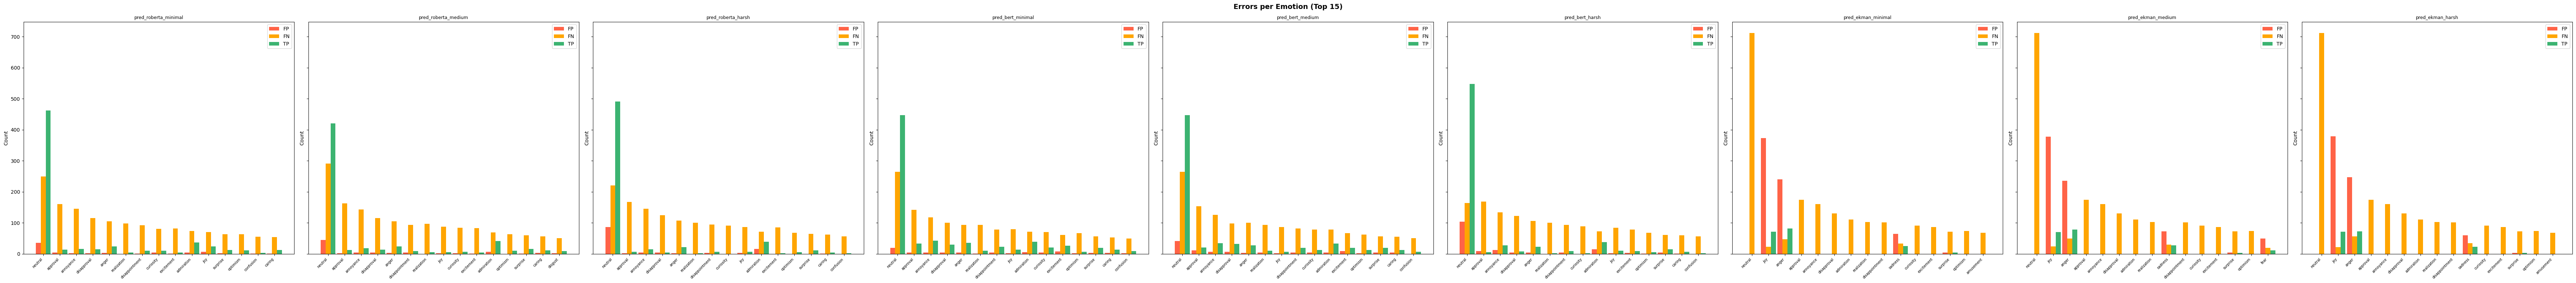

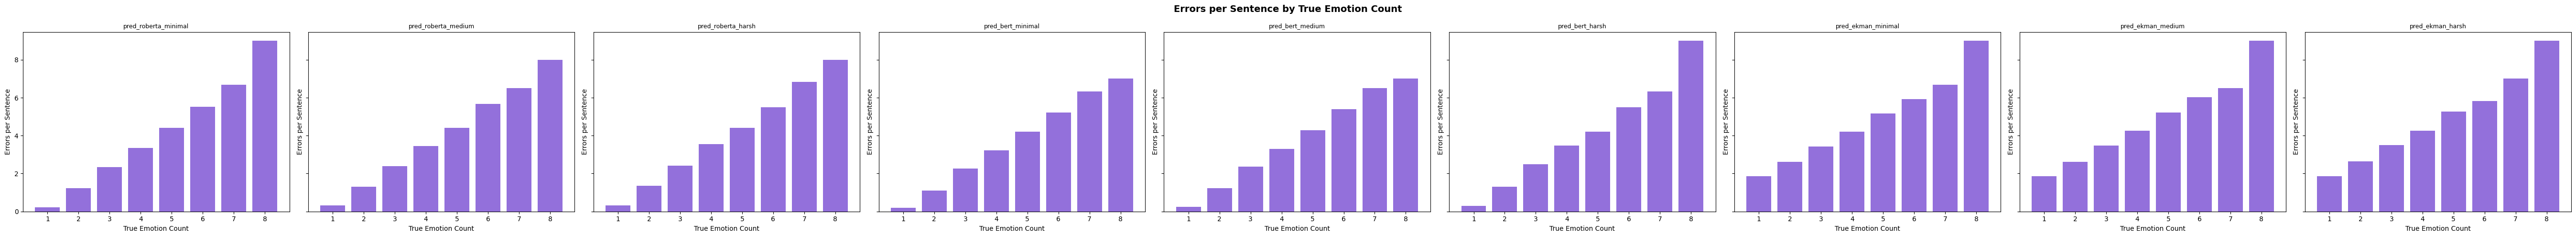

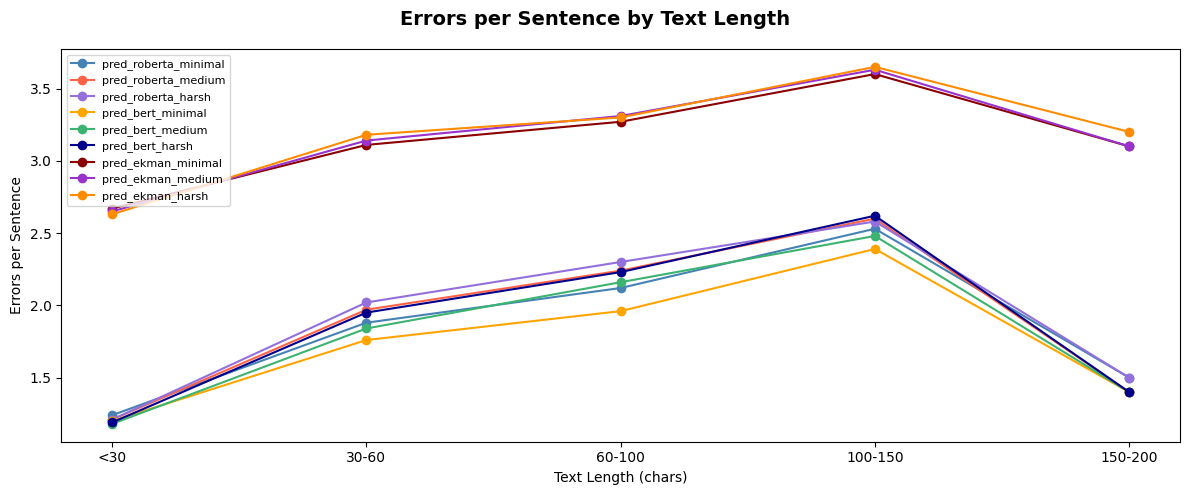

In [ ]:
# Run error analysis for all models
pred_cols = [col for col in test_data.columns if col.startswith("pred_") 
             and not col.endswith("_labels") and not col.endswith("_scores")]

run_error_analysis(test_data, pred_cols, emotion_cols)

# Side by side comparison for all models
compare_models_side_by_side(test_data, pred_cols, emotion_cols)

In [136]:
# Convert prediction dictionaries(binary) to lists(Strings) of predicted emotions and save them in new columns
for col in pred_cols:
    label_col = f"{col}_labels"
    test_data[label_col] = test_data[col].apply(prediction_to_labels)

# Display the first few rows of the relevant columns to verify the label conversion
test_data[['true_emotions_label',
           'pred_roberta_minimal_labels',
           'pred_roberta_medium_labels',
           'pred_roberta_harsh_labels']].head()

,true_emotions_label,pred_roberta_minimal_labels,pred_roberta_medium_labels,pred_roberta_harsh_labels
0,"[anger, annoyance, approval, optimism, neutral]",[neutral],[neutral],[neutral]
1,"[curiosity, love]",[love],[love],[love]
2,[surprise],[surprise],[surprise],[surprise]
3,[neutral],[neutral],[neutral],[neutral]
4,[neutral],[neutral],[neutral],[neutral]


In [137]:
# Set the prediction columns for evaluation
prediction_cols = {
    'Minimal Preprocessing Roberta': 'pred_roberta_minimal',
    'Medium Preprocessing Roberta': 'pred_roberta_medium',
    'Harsh Preprocessing Roberta': 'pred_roberta_harsh',
    'Minimal Preprocessing BERT': 'pred_bert_minimal',
    'Medium Preprocessing BERT': 'pred_bert_medium',
    'Harsh Preprocessing BERT': 'pred_bert_harsh',
    'Minimal Preprocessing Ekman': 'pred_ekman_minimal',
    'Medium Preprocessing Ekman': 'pred_ekman_medium',
    'Harsh Preprocessing Ekman': 'pred_ekman_harsh'
}

print("Prediction columns in the dataset:")
for col in prediction_cols.values():
    print(f"  - {col}")

Prediction columns in the dataset:
  - pred_roberta_minimal
  - pred_roberta_medium
  - pred_roberta_harsh
  - pred_bert_minimal
  - pred_bert_medium
  - pred_bert_harsh
  - pred_ekman_minimal
  - pred_ekman_medium
  - pred_ekman_harsh


In [138]:
# Create a comparison DataFrame for evaluation
comparison_df = create_model_comparison_df(
    df=test_data,  # or dataset_with_predictions
    emotion_cols=emotion_cols,
    prediction_cols=prediction_cols
)

#Display the first few rows of the comparison DataFrame to verify it was created correctly
comparison_df.head(9)

,model,micro_f1,macro_f1,samples_f1,weighted_f1,exact_match_ratio,hamming_loss,micro_precision,micro_recall,macro_precision,macro_recall,total_samples,error_count
0,Minimal Preprocessing Roberta,0.450274,0.271344,0.505505,0.400700,0.180,0.068107,0.909197,0.299234,0.744920,0.181569,1000,0
1,Medium Preprocessing Roberta,0.428198,0.269679,0.480395,0.382372,0.167,0.070393,0.881720,0.282759,0.708697,0.183553,1000,0
2,Harsh Preprocessing Roberta,0.425544,0.228792,0.481357,0.355424,0.168,0.071643,0.842404,0.284674,0.665154,0.160162,1000,0
3,Minimal Preprocessing BERT,0.501531,0.346688,0.571834,0.472669,0.185,0.063964,0.916582,0.345211,0.752291,0.235041,1000,0
4,Medium Preprocessing BERT,0.473934,0.325399,0.541779,0.439295,0.180,0.067393,0.870010,0.325670,0.729044,0.222488,1000,0
5,Harsh Preprocessing BERT,0.454444,0.244778,0.522302,0.381060,0.175,0.070143,0.826263,0.313410,0.730792,0.168188,1000,0
6,Minimal Preprocessing Ekman,0.116620,0.058801,0.101971,0.048789,0.005,0.112000,0.220213,0.079310,0.070739,0.087739,1000,0
7,Medium Preprocessing Ekman,0.113419,0.055052,0.100600,0.046099,0.005,0.112786,0.212185,0.077395,0.064948,0.086258,1000,0
8,Harsh Preprocessing Ekman,0.108763,0.053341,0.094974,0.043963,0.005,0.112964,0.205538,0.073946,0.067543,0.082919,1000,0


In [139]:
# Calculate the best model based on Macro F1 score
best_model = comparison_df.loc[comparison_df['macro_f1'].idxmax(), 'model']
best_f1 = comparison_df.loc[comparison_df['macro_f1'].idxmax(), 'macro_f1']
print(f"\n Best model based on Macro F1: {best_model} ({best_f1:.4f})")


 Best model based on Macro F1: Minimal Preprocessing BERT (0.3467)


                   admiration_TP  admiration_FP  admiration_FN  amusement_TP  \
admiration_TP                  0              0              0             0   
admiration_FP                  0              0              0             0   
admiration_FN                  0              0              0             4   
amusement_TP                   0              0              4             0   
amusement_FP                   0              0              0             0   
amusement_FN                   0              0              6             0   
anger_TP                       0              0              1             0   
anger_FP                       0              0              0             0   
anger_FN                       1              0              1             4   
annoyance_TP                   0              0              1             0   
annoyance_FP                   0              0              0             0   
annoyance_FN                   1        

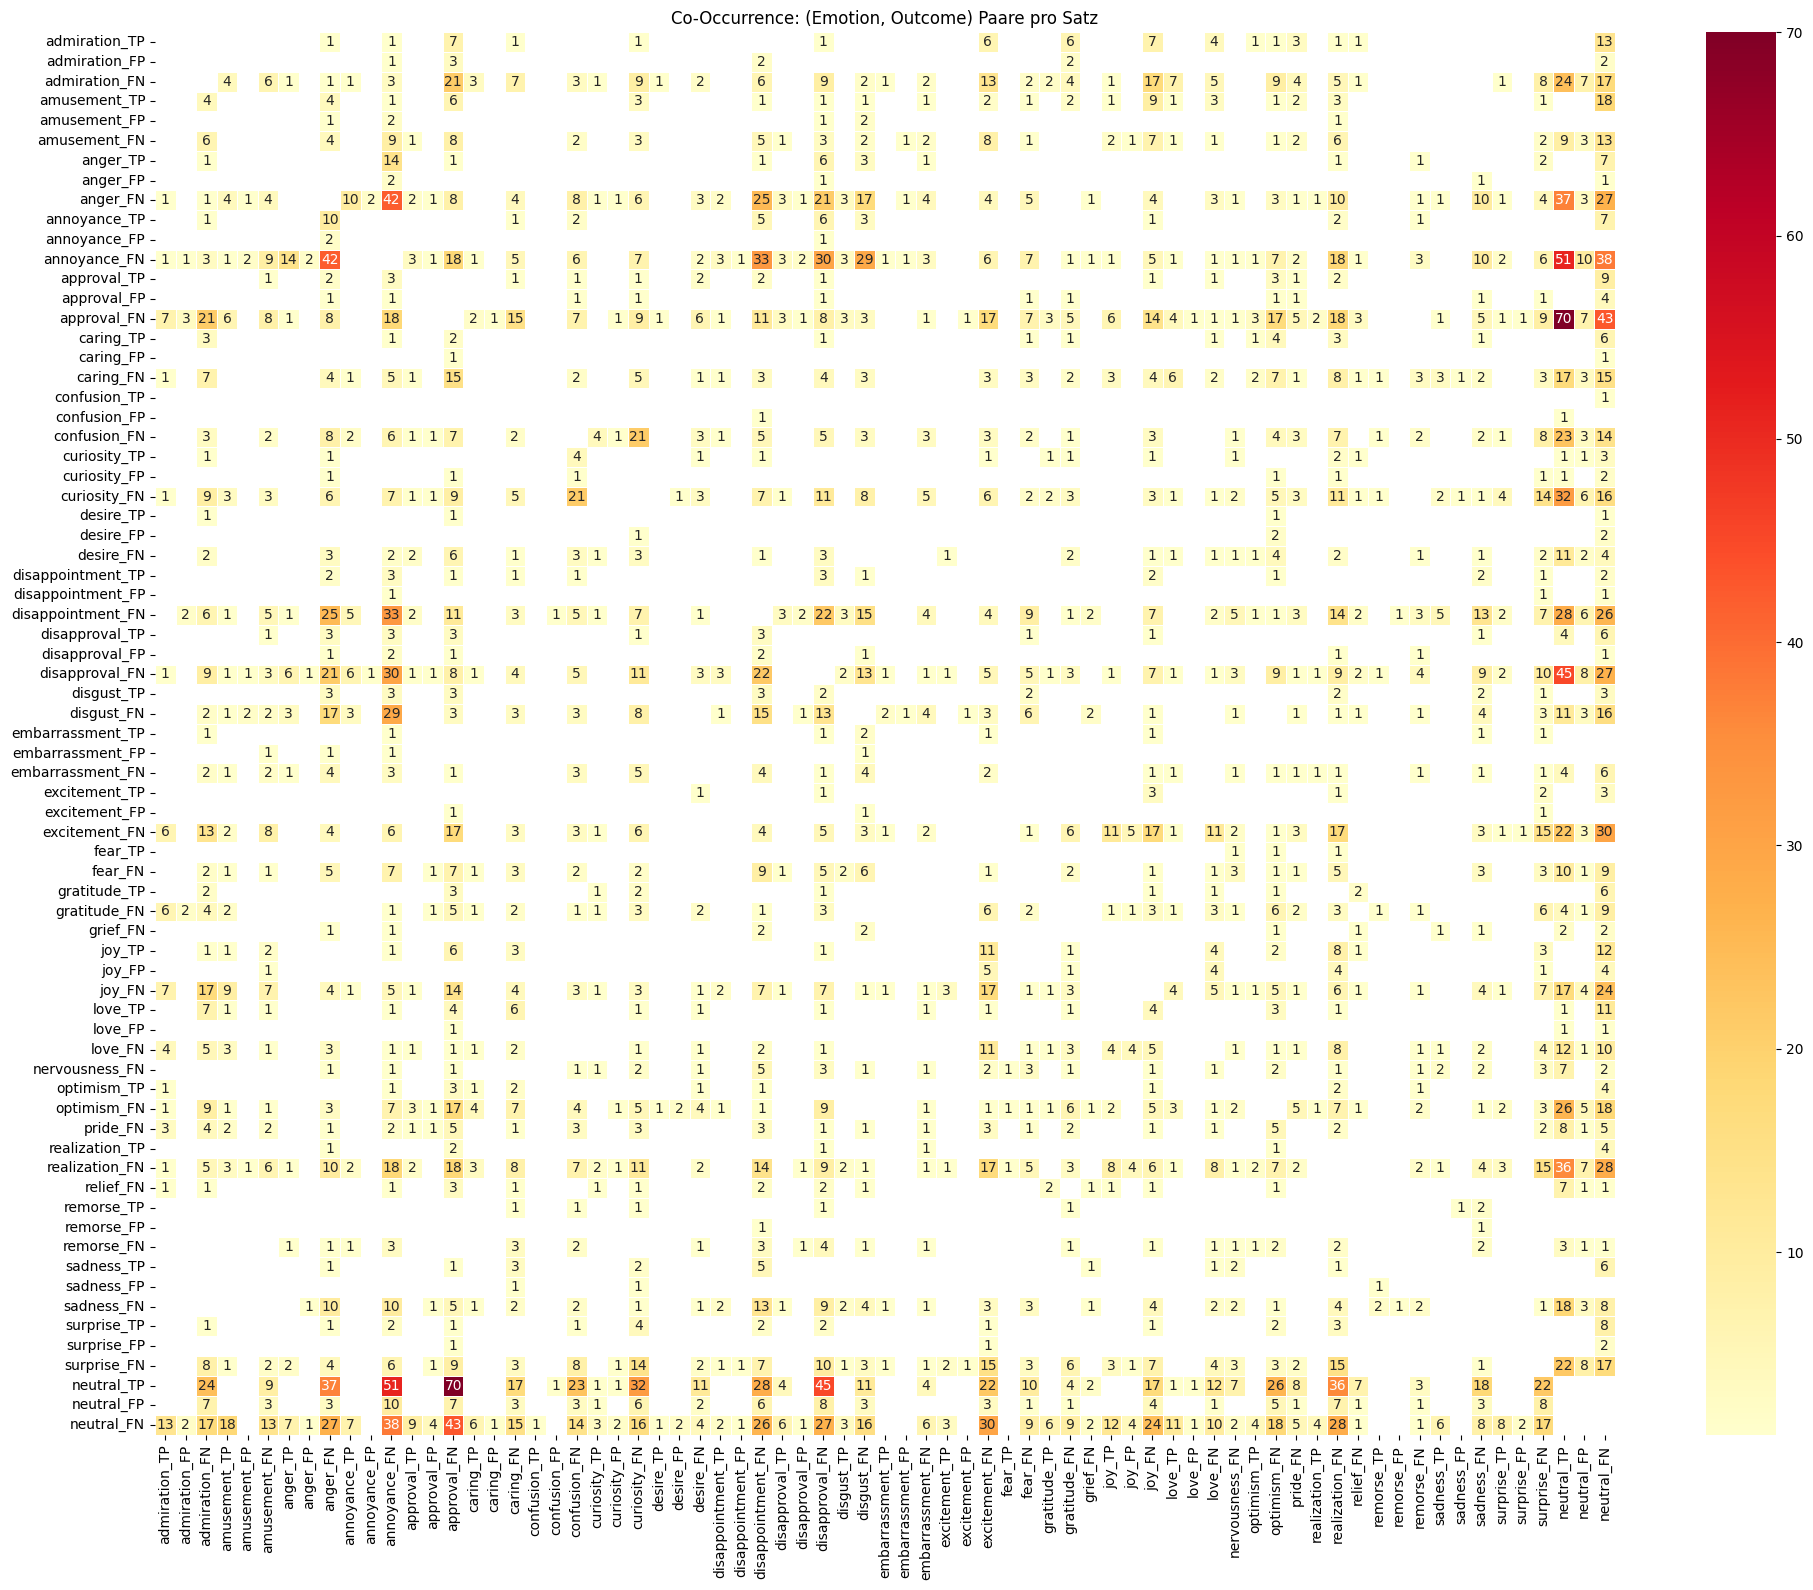

In [140]:
from itertools import combinations
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def build_cooccurrence_table(true_df, pred_series, emotion_cols):
    
    pred_binary = pd.DataFrame(0, index=pred_series.index, columns=emotion_cols)
    for idx, pred in enumerate(pred_series):
        if isinstance(pred, dict):
            for emotion, val in pred.items():
                if emotion in emotion_cols and val == 1:
                    pred_binary.iloc[idx][emotion] = 1

    all_labels = []
    for e in emotion_cols:
        for outcome in ["TP", "FP", "FN"]:
            all_labels.append(f"{e}_{outcome}")

    matrix = pd.DataFrame(0, index=all_labels, columns=all_labels)

    for i in range(len(true_df)):
        true_row = true_df[emotion_cols].iloc[i]
        pred_row = pred_binary.iloc[i]

        row_labels = []
        for e in emotion_cols:
            t = true_row[e]
            p = pred_row[e]
            if p == 1 and t == 1:
                row_labels.append(f"{e}_TP")
            elif p == 1 and t == 0:
                row_labels.append(f"{e}_FP")
            elif p == 0 and t == 1:
                row_labels.append(f"{e}_FN")

        for a, b in combinations(row_labels, 2):
            matrix.loc[a, b] += 1
            matrix.loc[b, a] += 1

    mask = matrix.sum(axis=1) > 0
    matrix = matrix.loc[mask, mask]

    return matrix, pred_binary  # <-- pred_binary auch zurückgeben

# Ausführen
cooc, pred_binary = build_cooccurrence_table(
    true_df=test_data,
    pred_series=test_data["pred_roberta_minimal"],
    emotion_cols=emotion_cols
)


# Tabelle anzeigen
print(cooc)

# Heatmap
plt.figure(figsize=(20, 16))
cooc_masked = cooc.where(cooc > 0)
sns.heatmap(cooc_masked, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Co-Occurrence: (Emotion, Outcome) Paare pro Satz")
plt.tight_layout()
plt.show()

In [141]:
summary = pd.DataFrame([
    {
        "emotion": e,
        "TP": int(((pred_binary[e] == 1) & (test_data[e] == 1)).sum()),
        "FP": int(((pred_binary[e] == 1) & (test_data[e] == 0)).sum()),
        "FN": int(((pred_binary[e] == 0) & (test_data[e] == 1)).sum()),
        "TN": int(((pred_binary[e] == 0) & (test_data[e] == 0)).sum()),
    }
    for e in emotion_cols
]).set_index("emotion")

print(summary)

                 TP  FP   FN   TN
emotion                          
admiration       37   4   74  885
amusement        36   3   32  929
anger            24   3  105  868
annoyance        16   2  145  837
approval         14   4  161  821
caring           13   1   54  932
confusion         3   1   55  941
curiosity        10   4   81  905
desire            1   2   23  974
disappointment   10   1   92  897
disapproval      15   2  115  868
disgust           8   0   52  940
embarrassment     5   1   16  978
excitement        5   1   82  912
fear              3   0   27  970
gratitude        18   0   25  957
grief             0   0    5  995
joy              24   7   70  899
love             28   2   37  933
nervousness       0   0   16  984
optimism         11   0   63  926
pride             0   0   18  982
realization       5   0   98  897
relief            0   0   15  985
remorse           6   1   11  982
sadness          14   1   44  941
surprise         13   2   63  922
neutral       

In [142]:
# Every Pair with count > 10
high_cooc = []

for i in range(len(cooc.index)):
    for j in range(i+1, len(cooc.columns)):  # nur oberes Dreieck, keine Duplikate
        val = cooc.iloc[i, j]
        if val > 10:
            high_cooc.append({
                "emotion_outcome_1": cooc.index[i],
                "emotion_outcome_2": cooc.columns[j],
                "count": int(val)
            })

high_cooc_df = pd.DataFrame(high_cooc).sort_values("count", ascending=False)
pd.set_option('display.max_rows', None)
print(high_cooc_df)

    emotion_outcome_1  emotion_outcome_2  count
28        approval_FN         neutral_TP     70
20       annoyance_FN         neutral_TP     51
48     disapproval_FN         neutral_TP     45
29        approval_FN         neutral_FN     43
9            anger_FN       annoyance_FN     42
21       annoyance_FN         neutral_FN     38
13           anger_FN         neutral_TP     37
67     realization_FN         neutral_TP     36
16       annoyance_FN  disappointment_FN     33
38       curiosity_FN         neutral_TP     32
17       annoyance_FN     disapproval_FN     30
58      excitement_FN         neutral_FN     30
18       annoyance_FN         disgust_FN     29
45  disappointment_FN         neutral_TP     28
68     realization_FN         neutral_FN     28
14           anger_FN         neutral_FN     27
49     disapproval_FN         neutral_FN     27
64        optimism_FN         neutral_TP     26
46  disappointment_FN         neutral_FN     26
10           anger_FN  disappointment_FN

In [145]:
test_data.to_csv("../data/test_data_with_predictions.csv", index=False)

In [144]:
rows = []

# True emotions
true_counts = test_data[emotion_cols].sum(axis=1)
rows.append({
    "Model": "True Labels",
    "More than 1": int((true_counts > 1).sum()),
    "More than 1 (%)": f"{(true_counts > 1).mean() * 100:.1f}%",
    "More than 2": int((true_counts > 2).sum()),
    "More than 2 (%)": f"{(true_counts > 2).mean() * 100:.1f}%",
})

# Per experiment
for text_col, model_key, output_col in experiments:
    if output_col not in test_data.columns:
        continue

    pb = pd.DataFrame(0, index=test_data.index, columns=emotion_cols)
    for idx, pred in enumerate(test_data[output_col]):
        if isinstance(pred, dict):
            for emotion, val in pred.items():
                if emotion in emotion_cols and val == 1:
                    pb.loc[pb.index[idx], emotion] = 1

    pred_counts = pb.sum(axis=1)
    rows.append({
        "Model": f"{model_key} – {text_col}",
        "More than 1": int((pred_counts > 1).sum()),
        "More than 1 (%)": f"{(pred_counts > 1).mean() * 100:.1f}%",
        "More than 2": int((pred_counts > 2).sum()),
        "More than 2 (%)": f"{(pred_counts > 2).mean() * 100:.1f}%",
    })

cardinality_df = pd.DataFrame(rows).set_index("Model")
print(cardinality_df)

                                             More than 1 More than 1 (%)  \
Model                                                                      
True Labels                                          795           79.5%   
roberta_baseline – 01_minimal_preprocessing           16            1.6%   
roberta_baseline – 02_medium_preprocessing             8            0.8%   
roberta_baseline – 03_harsh_preprocessing              6            0.6%   
bert_baseline – 01_minimal_preprocessing               0            0.0%   
bert_baseline – 02_medium_preprocessing                0            0.0%   
bert_baseline – 03_harsh_preprocessing                 0            0.0%   
ekman_baseline – 01_minimal_preprocessing              0            0.0%   
ekman_baseline – 02_medium_preprocessing               0            0.0%   
ekman_baseline – 03_harsh_preprocessing                0            0.0%   

                                             More than 2 More than 2 (%)  
Model       

In [146]:
# ── SENTIMENT ANALYSIS ──────────────────────────────────────────────────────
sentiment_map = {
    "positive": ["admiration", "amusement", "approval", "caring", "curiosity",
                 "desire", "excitement", "gratitude", "joy", "love", "optimism",
                 "pride", "relief"],
    "negative": ["anger", "annoyance", "disappointment", "disapproval", "disgust",
                 "embarrassment", "fear", "grief", "nervousness", "remorse", "sadness"],
    "neutral":  ["neutral", "confusion", "realization", "surprise"]
}

# Reverse map: emotion → sentiment
emotion_to_sentiment = {e: s for s, emotions in sentiment_map.items() for e in emotions}

def get_sentiment(emotion_list):
    """Returns dominant sentiment from a list of emotions."""
    sentiments = [emotion_to_sentiment[e] for e in emotion_list if e in emotion_to_sentiment]
    if not sentiments:
        return "neutral"
    return Counter(sentiments).most_common(1)[0][0]

# Get true and predicted emotion lists per sentence
true_emotion_lists = test_data[emotion_cols].apply(
    lambda row: [e for e in emotion_cols if row[e] == 1], axis=1
)
pred_emotion_lists = pred_binary.apply(
    lambda row: [e for e in emotion_cols if row[e] == 1], axis=1
)

# Get sentiment per sentence
true_sentiment = true_emotion_lists.apply(get_sentiment)
pred_sentiment = pred_emotion_lists.apply(get_sentiment)

# Compare
sentiment_df = pd.DataFrame({
    "True Sentiment": true_sentiment,
    "Predicted Sentiment": pred_sentiment,
    "Correct": true_sentiment == pred_sentiment
})

print("=== Sentiment Accuracy ===")
print(f"Correct: {sentiment_df['Correct'].sum()} / {len(sentiment_df)} ({sentiment_df['Correct'].mean()*100:.1f}%)")

print("\n=== Confusion Matrix ===")
print(pd.crosstab(sentiment_df["True Sentiment"], sentiment_df["Predicted Sentiment"]))

=== Sentiment Accuracy ===
Correct: 529 / 1000 (52.9%)

=== Confusion Matrix ===
Predicted Sentiment  negative  neutral  positive
True Sentiment                                  
negative                   94      198        15
neutral                     2      247        17
positive                   15      224       188


sentiment_map = {
    "positive": ["admiration", "amusement", "approval", "caring", "curiosity",
                 "desire", "excitement", "gratitude", "joy", "love", "optimism",
                 "pride", "relief"],
    "negative": ["anger", "annoyance", "disappointment", "disapproval", "disgust",
                 "embarrassment", "fear", "grief", "nervousness", "remorse", "sadness"]
}

emotion_to_sentiment = {e: s for s, emotions in sentiment_map.items() for e in emotions}

def get_sentiment(emotion_list):
    sentiments = [emotion_to_sentiment[e] for e in emotion_list if e in emotion_to_sentiment]
    if not sentiments:
        return None  # neutral/ambiguous emotions werden ignoriert
    return Counter(sentiments).most_common(1)[0][0]

true_sentiment = true_emotion_lists.apply(get_sentiment)
pred_sentiment = pred_emotion_lists.apply(get_sentiment)

# Only keep sentences where both have a sentiment (no None)
mask = true_sentiment.notna() & pred_sentiment.notna()
true_sentiment = true_sentiment[mask]
pred_sentiment = pred_sentiment[mask]

sentiment_df = pd.DataFrame({
    "True Sentiment": true_sentiment,
    "Predicted Sentiment": pred_sentiment,
    "Correct": true_sentiment == pred_sentiment
})

print("=== Sentiment Accuracy (Positive / Negative only) ===")
print(f"Sentences evaluated: {len(sentiment_df)}")
print(f"Correct: {sentiment_df['Correct'].sum()} ({sentiment_df['Correct'].mean()*100:.1f}%)")

print("\n=== Confusion Matrix ===")
print(pd.crosstab(sentiment_df["True Sentiment"], sentiment_df["Predicted Sentiment"]))